# Assignment Module 2: Aircraft Classification

The goal of this assignment is to implement a neural network that classifies images of 100 aircraft model variants from the [Fine-Grained Visual Classification of Aircraft (**FGVC-Aircraft**) dataset](https://www.robots.ox.ac.uk/~vgg/data/fgvc-aircraft/). The assignment is divided into two parts: first, you will be asked to implement your own neural network for image classification from scratch; then, you will fine-tune a pretrained network provided by PyTorch.


![FGVC-Aircraft variants](https://raw.githubusercontent.com/CVLAB-Unibo/ipcv-assignment-2/master/fgvc_aircraft_variants.svg)


## Environment, reproducibility and device selection

This cell imports the libraries that will be used in the notebook and fixes the random seeds. Deterministic CUDA behavior has been chosen so that model and ablation results can be compared under reproducible conditions. 

In [1]:
import copy
import os
import random
import time
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import ResNet18_Weights, resnet18
from torchvision.transforms import InterpolationMode
import torch.nn.functional as F
from pathlib import Path
from PIL import Image, ImageOps
from tqdm import tqdm

SEED = 42

def fix_randomness(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.use_deterministic_algorithms(True, warn_only=True)  # for deterministic behaviour
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):  # for the initialization of DataLoader workers
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

fix_randomness()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # selects CUDA GPU if available
print(f"Using device: {device}")


Using device: cuda


## Dataset and preprocessing

The dataset is loaded through [`torchvision.datasets.FGVCAircraft`](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.FGVCAircraft.html) with `annotation_level="variant"`.

The three official dataset splits have distinct roles:
* The Training set is used for parameters updates and training-only data augmentation;
* The Validation set is used for checkpoint selection, learning rate scheduler decision, hyperparameter comparison and for all the ablation studies;
* The Test set is used exclusively for analyzing and reporting the model's final generalization performance. 

In this notebook, the custom CNN is evaluated on the test split both after Part 1 as an intermediate descriptive result and in the final comparative table; the 2 ResNet-18 configurations are evaluated in the final section.

Images are resized to 256 pixels and subsequently cropped to
$224 \times 224$ pixels. Training uses batches of 64 images. 

### Aircraft bounding-box extraction

FGVC-Aircraft provides one bounding box for each image. Before applying any
resize or augmentation, `BBoxCropDataset` loads the original RGB image and
extracts the aircraft region.

Given the original bounding box

$$
(x_{\min}, y_{\min}, x_{\max}, y_{\max}),
$$

its width and height are

$$
w_b = x_{\max} - x_{\min},
\qquad
h_b = y_{\max} - y_{\min}.
$$

To reduce the risk of removing components near the annotation boundary,
the box is expanded using a margin $m=0.1$. The resulting coordinates are

$$
x'_{\min} = \max(0,\;x_{\min} - m w_b),
$$

$$
x'_{\max} = \min(W,\;x_{\max} + m w_b),
$$

$$
y'_{\min} = \max(0,\;y_{\min} - m h_b),
$$

$$
y'_{\max} = \min(H,\;y_{\max} + m h_b),
$$

where $W$ and $H$ are the width and height of the original image. The `max` and `min` operations prevent the expanded coordinates from exceeding the image boundaries.

A margin of $m=0.1$ adds 10% of the bounding-box dimension on each side.
Consequently, the extracted region can be up to 20% wider and taller than the original.

The wrapper keeps the original `classes` and `class_to_idx` attributes so that label information remains available to the rest of the pipeline.

### Training-set normalization

Channel statistics are estimated exclusively from cropped training images.
Validation and test images are not involved in this calculation, preventing information from these splits from influencing preprocessing decisions.

For every RGB channel $c$, the normalization operation is

$$
\hat{x}_c = \frac{x_c-\mu_c}{\sigma_c},
$$

where $\mu_c$ and $\sigma_c$ are the mean and standard deviation estimated from the training split.

### Training transformations

The training pipeline applies the following operations:

1. aspect-ratio-preserving resize to 256 pixels;
2. random $224 \times 224$ crop;
3. horizontal flip with probability $p=0.5$;
4. conversion to a PyTorch tensor;
5. channel-wise normalization.

Data augmentation is the application of realistic, label-preserving transformations to create additional training examples.
Random cropping exposes the network to different spatial views, while horizontal flipping encourages it to recognize an aircraft independently of its left-right orientation.
These stochastic transformations are used only during training.

### Validation and test transformations

Validation and test preprocessing is deterministic:

1. aspect-ratio-preserving resize to 256 pixels;
2. centered $224 \times 224$ crop;
3. conversion to a tensor;
4. normalization using the training statistics.

Using identical deterministic transformations for validation and test ensures that repeated evaluations remain comparable.

### Reproducible DataLoaders

`make_train_val_loaders` creates fresh DataLoaders for each experiment. A
seeded `torch.Generator` controls training-set shuffling, while
`seed_worker` initializes the random-number generators of each worker.
This ensures that the main model and its ablations begin from controlled
data-order conditions, making their comparison more reliable.


In [2]:
# configuration
DATA_ROOT = "./data"
RESIZE_SIZE = 256
CROP_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 0 if os.name == "nt" else 2  # on non-Windows systems, two DataLoader workers are used to load and transform images in parallel
PIN_MEMORY = device.type == "cuda"  # allowing batches to be transferred from CPU memory to the GPU more efficiently
BBOX_MARGIN = 0.1  # extra padding around the bounding box, as a fraction of its size

# bounding box loading
def load_bbox_dict(data_root):
    bbox_path = Path(data_root) / "fgvc-aircraft-2013b" / "data" / "images_box.txt"
    bbox_dict = {}
    with open(bbox_path) as f:
        for line in f:
            image_id, xmin, ymin, xmax, ymax = line.split()
            bbox_dict[image_id] = (int(xmin), int(ymin), int(xmax), int(ymax))
    return bbox_dict

# wrapper
class BBoxCropDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, bbox_dict, transform=None, margin=0.1):
        self.base_dataset = base_dataset
        self.bbox_dict = bbox_dict
        self.transform = transform
        self.margin = margin

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image_path = self.base_dataset._image_files[idx]
        label = self.base_dataset._labels[idx]
        image_id = Path(image_path).stem
        image = Image.open(image_path).convert("RGB")

        if image_id in self.bbox_dict:
            xmin, ymin, xmax, ymax = self.bbox_dict[image_id]
            w, h = image.size
            mx = (xmax - xmin) * self.margin
            my = (ymax - ymin) * self.margin
            xmin = max(0, xmin - mx)
            ymin = max(0, ymin - my)
            xmax = min(w, xmax + mx)
            ymax = min(h, ymax + my)
            image = image.crop((xmin, ymin, xmax, ymax))

        if self.transform is not None:
            image = self.transform(image)
        return image, label

    @property
    def classes(self):
        return self.base_dataset.classes

    @property
    def class_to_idx(self):
        return self.base_dataset.class_to_idx


# for mean and standard deviation
def compute_mean_std(dataset):
    loader = DataLoader(dataset, batch_size=64, num_workers=NUM_WORKERS)
    mean = torch.zeros(3)
    std = torch.zeros(3)
    n = 0
    for x, _ in loader:
        b = x.size(0)
        x = x.view(b, 3, -1)
        mean += x.mean(dim=2).sum(dim=0)
        std += x.std(dim=2).sum(dim=0)
        n += b
    return mean / n, std / n


# base datasets
base_train = datasets.FGVCAircraft(root=DATA_ROOT, split="train", annotation_level="variant", download=True, transform=None)
base_val   = datasets.FGVCAircraft(root=DATA_ROOT, split="val",   annotation_level="variant", download=True, transform=None)
base_test  = datasets.FGVCAircraft(root=DATA_ROOT, split="test",  annotation_level="variant", download=True, transform=None)

bbox_dict = load_bbox_dict(DATA_ROOT)

raw_transform = transforms.Compose([
    transforms.Resize(RESIZE_SIZE, interpolation=InterpolationMode.BILINEAR, antialias=True),
    transforms.CenterCrop(CROP_SIZE),
    transforms.ToTensor(),
])
stats_dataset = BBoxCropDataset(base_train, bbox_dict, transform=raw_transform, margin=BBOX_MARGIN)
mean, std = compute_mean_std(stats_dataset)
print(f"Mean={mean}, Std={std}")

AIRCRAFT_MEAN = mean.tolist()
AIRCRAFT_STD = std.tolist()
normalize = transforms.Normalize(mean=AIRCRAFT_MEAN, std=AIRCRAFT_STD)

train_transform = transforms.Compose([
    transforms.Resize(RESIZE_SIZE, interpolation=InterpolationMode.BILINEAR, antialias=True),
    transforms.RandomCrop(CROP_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    normalize,
])
eval_transform = transforms.Compose([
    transforms.Resize(RESIZE_SIZE, interpolation=InterpolationMode.BILINEAR, antialias=True),
    transforms.CenterCrop(CROP_SIZE),
    transforms.ToTensor(),
    normalize,
])

print("Loading datasets...")
train_dataset = BBoxCropDataset(base_train, bbox_dict, transform=train_transform, margin=BBOX_MARGIN)
val_dataset   = BBoxCropDataset(base_val,   bbox_dict, transform=eval_transform,  margin=BBOX_MARGIN)
test_dataset  = BBoxCropDataset(base_test,  bbox_dict, transform=eval_transform,  margin=BBOX_MARGIN)

# checks to prevent silent label-index mismatches across splits
assert train_dataset.class_to_idx == val_dataset.class_to_idx
assert train_dataset.class_to_idx == test_dataset.class_to_idx
num_classes = len(train_dataset.classes)
assert num_classes == 100, f"Expected 100 variants, found {num_classes}"

def make_train_val_loaders(seed=SEED):  # create fresh loaders so each experiment starts with the same RNG state
    generator = torch.Generator().manual_seed(seed)
    common = {
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
        "worker_init_fn": seed_worker,
        "persistent_workers": NUM_WORKERS > 0,
    }
    return {
        "train": DataLoader(train_dataset, shuffle=True, generator=generator, **common),
        "val": DataLoader(val_dataset, shuffle=False, **common),
    }

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker,
    persistent_workers=NUM_WORKERS > 0,
)

print(f"Classes:    {num_classes}")
print(f"Training:   {len(train_dataset):,}")
print(f"Validation: {len(val_dataset):,}")
print(f"Test:       {len(test_dataset):,}")

100%|██████████| 2.75G/2.75G [01:47<00:00, 25.7MB/s]


Mean=tensor([0.4850, 0.5084, 0.5282]), Std=tensor([0.2364, 0.2357, 0.2504])
Loading datasets...
Classes:    100
Training:   3,334
Validation: 3,333
Test:       3,333


## Part 1: design your own network

Your goal is to implement a convolutional neural network for image classification and train it from scratch on `FGVCAircraft`. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~50%. You are free to achieve this however you want, except for a few rules you must follow:

- Compile this notebook by displaying the results obtained by the best model you found throughout your experimentation; then show how, by removing some of its components, its performance drops. In other words, do an *ablation study* to prove that your design choices have a positive impact on the final result.

- Do not instantiate an off-the-self PyTorch network. Instead, construct your network as a composition of existing PyTorch layers. In more concrete terms, you can use e.g. `torch.nn.Linear`, but you cannot use e.g. `torchvision.models.alexnet`.

- Show your results and ablations with plots, tables, images, etc. — the clearer, the better.

Don't be too concerned with your model performance: the ~50% is just to give you an idea of when to stop. Keep in mind that a thoroughly justified model with lower accuracy will be rewarded more points than a poorly experimentally validated model with higher accuracy.


## Our Custom Network

## Custom residual network

The custom network follows the residual-learning principles.

### Residual block

Each `ResidualBlock` contains a main path composed of two $3 \times 3$ convolutions:

$$
x
\;\longrightarrow\;
\operatorname{Conv}_{3 \times 3}
\;\longrightarrow\;
\operatorname{BN}
\;\longrightarrow\;
\operatorname{ReLU}
\;\longrightarrow\;
\operatorname{Conv}_{3 \times 3}
\;\longrightarrow\;
\operatorname{BN}
\;\longrightarrow\;
F(x).
$$

No activation is applied after the second Batch Normalization and before the residual addition. This allows the residual perturbation $F(x)$ to contain both positive and negative values.

When the input and output dimensions are equal, the residual block computes

$$
y = \operatorname{ReLU}\left(F(x)+x\right).
$$

Instead of learning the complete desired mapping directly, the convolutional path only learns the residual perturbation $F(x)$ that must be added to the identity representation $x$. This makes an identity mapping easy to represent: if the optimal residual is close to zero, the block can simply propagate its input through the shortcut.

This is particularly useful for FGVC-Aircraft Dataset, where the model requires enough capacity to distinguish subtle differences in engines, wings, windows, and tails of the aircrafts without making optimization unstable.

### Projection shortcut

Element-wise addition requires the main path and shortcut to have identical spatial and channel dimensions.

If the spatial resolution or number of channels changes, the identity shortcut is replaced by a learned projection:

$$
x
\;\longrightarrow\;
\operatorname{Conv}_{1 \times 1}
\;\longrightarrow\;
\operatorname{BN}
\;\longrightarrow\;
S(x).
$$

The complete block then becomes

$$
y =
\operatorname{ReLU}
\left(
F(x)+S(x)
\right).
$$

The $1 \times 1$ convolution uses the same stride as the first convolution in the main path. It therefore reduces the spatial dimensions when the stride is 2 and projects the input into the required number of output channels. 

### Batch Normalization

Each convolution is followed by Batch Normalization when `use_batchnorm=True`.
Batch Normalization keeps the residual signal $F(x)$ on a controlled scale before it is added to the shortcut. This reduces the risk that the learned perturbation overwhelms the identity representation.
Convolutional biases are disabled when Batch Normalization is present because Batch Normalization already includes a learnable offset. When Batch Normalization is removed, `nn.Identity` replaces it and convolutional biases are enabled again.

### Stochastic depth

The model uses mild stochastic-depth regularization. During training, the convolutional path of a residual block may be skipped, leaving only the shortcut. Precisely, entire residual branches are randomly skipped during the training phase, while the complete network is used for the evaluation phase.

The first residual block is therefore always active, while the drop probability increases gradually to 0.1 for the deepest block.
This exposes the model to subnetworks with different effective depths during training. At evaluation time, all residual blocks are active and the complete network is used. Stochastic depth is disabled when residual connections are removed because a skipped main path would leave no valid route through the block.

### Network architecture

`CustomNet` starts with a $3 \times 3$ convolution and contains four residual stages. Each stage is composed of two residual blocks.

| Component | Output channels/features | Stride pattern | Output spatial size |
|---|---:|---:|---:|
| Input | 3 | - | $224 \times 224$ |
| Initial $3 \times 3$ convolution | 32 | 1 | $224 \times 224$ |
| $3 \times 3$ max pooling | 32 | 2 | $112 \times 112$ |
| Residual stage 1 | 32 | $1, 1$ | $112 \times 112$ |
| Residual stage 2 | 64 | $2, 1$ | $56 \times 56$ |
| Residual stage 3 | 128 | $2, 1$ | $28 \times 28$ |
| Residual stage 4 | 256 | $2, 1$ | $14 \times 14$ |
| Adaptive global average pooling | 256 | - | $1 \times 1$ |
| Linear classifier | 100 outputs | - | 100 class scores |

The first block of stages 2–4 uses stride 2, halving the spatial resolution:

$$
H_{\mathrm{out}} = \frac{H_{\mathrm{in}}}{2},
\qquad
W_{\mathrm{out}} = \frac{W_{\mathrm{in}}}{2}.
$$

At the same time, the number of channels is doubled:

$$
C_{\mathrm{out}} = 2C_{\mathrm{in}}.
$$

Lower spatial resolution reduces computational cost, while additional channels increase the capacity available for higher-level visual representations.

### Global average pooling and classification

After the final residual stage, adaptive global average pooling converts each feature channel into one scalar. So, the resulting tensor has shape $256 \times 1 \times 1$.

In this way the tensor is flattened into a 256-dimensional vector and passed to the final linear classifier:

$$
s = Wz+b,
$$

where $ s \in \mathbb{R}^{100}$ 
contains one classification score for each aircraft variant.

Global average pooling avoids a large fully connected head, reducing the number of parameters and helping control overfitting.

In [3]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None,
                 drop_prob=0.0, use_batchnorm=True, use_skip=True):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, padding=1, bias=not use_batchnorm)
        self.bn1 = nn.BatchNorm2d(out_channels) if use_batchnorm else nn.Identity()
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=not use_batchnorm)
        self.bn2 = nn.BatchNorm2d(out_channels) if use_batchnorm else nn.Identity()
        # downsample is still built even when use_skip=False for the ablation studies
        # it is never invoked in forward() when the skip connection is disabled.
        self.downsample = downsample
        self.drop_prob = drop_prob
        self.use_skip = use_skip

    def forward(self, x):
        if not self.use_skip:
            # Plain conv-BN-ReLU stack: no identity shortcut, no stochastic depth (there is nothing to skip to). 
            # The main path alone already handles any stride/channel change via conv1.
            out = F.relu(self.bn1(self.conv1(x)))
            out = self.bn2(self.conv2(out))
            return F.relu(out)

        identity = x
        if self.downsample is not None:
            identity = self.downsample(x)

        if self.training and self.drop_prob > 0 and torch.rand(1).item() < self.drop_prob:
            return F.relu(identity)

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + identity
        return F.relu(out)


class CustomNet(nn.Module):
    def __init__(self, num_classes=100, max_drop_prob=0.1, use_batchnorm=True, use_skip=True):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=not use_batchnorm)
        self.bn1 = nn.BatchNorm2d(32) if use_batchnorm else nn.Identity()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        total_blocks = 8
        drop_probs = [max_drop_prob * i / (total_blocks - 1) for i in range(total_blocks)]
        it = iter(drop_probs)

        self.layer1 = self._make_layer(32, 32, 2, 1, [next(it), next(it)], use_batchnorm, use_skip)
        self.layer2 = self._make_layer(32, 64, 2, 2, [next(it), next(it)], use_batchnorm, use_skip)
        self.layer3 = self._make_layer(64, 128, 2, 2, [next(it), next(it)], use_batchnorm, use_skip)
        self.layer4 = self._make_layer(128, 256, 2, 2, [next(it), next(it)], use_batchnorm, use_skip)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, in_channels, out_channels, blocks, stride, drop_probs, use_batchnorm, use_skip):
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample_layers = [nn.Conv2d(in_channels, out_channels, 1, stride, bias=not use_batchnorm)]
            if use_batchnorm:
                downsample_layers.append(nn.BatchNorm2d(out_channels))
            downsample = nn.Sequential(*downsample_layers)
        layers = [ResidualBlock(in_channels, out_channels, stride, downsample,
                                 drop_prob=drop_probs[0], use_batchnorm=use_batchnorm, use_skip=use_skip)]
        for i in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels,
                                         drop_prob=drop_probs[i], use_batchnorm=use_batchnorm, use_skip=use_skip))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


## Training and evaluation utilities

The selected loss is cross-entropy. 

### Mixup

Mixup is enabled when `mixup_alpha` is greater than zero. Consider two training samples: then a mixing coefficient is sampled from a beta distribution. 
The new training input is obtained through linear interpolation in the input space. The corresponding target is interpolated in the one-hot label space.
Our implementation computes the equivalent weighted cross-entropy loss.

$$
\mathcal{L}_{\mathrm{Mixup}}
=
\lambda
\mathcal{L}
\left(
f(x),y^{(i)}
\right)
+
(1-\lambda)
\mathcal{L}
\left(
f(x),y^{(j)}
\right).
$$

We decided to use the Mixup technique because it forces the network to behave more linearly between training examples and produces smoother transitions between class decision boundaries and these effects can improve generalization. Mixup is applied only during training. Validation and test samples are evaluated without input or label mixing.

Notice that a standard training accuracy would compare the prediction only with $y^{(a)}$. This would be misleading whenever the second sample dominates
the mixture. For example, if $\lambda=0.1$, the mixed image contains only 10% of class $y^{(a)}$ and 90% of class $y^{(b)}$, but a comparison with
$y^{(a)}$ alone would mark a prediction of $y^{(b)}$ as entirely incorrect.

To account for both target contributions, the training loop uses a Mixup-weighted accuracy. For a batch of size $B$, it is defined as

$$
a_{\mathrm{Mixup}}
=
\frac{1}{B}
\sum_{i=1}^{B}
\left[
\lambda\,
\mathbb{I}
\left(
\hat{y}_i=y_i^{(a)}
\right)
+
(1-\lambda)\,
\mathbb{I}
\left(
\hat{y}_i=y_i^{(b)}
\right)
\right].
$$

A prediction matching the first label receives credit $\lambda$, while a prediction matching the second label receives credit $1-\lambda$. When
Mixup is disabled, the code returns to standard accuracy. This correction changes only the reported training metric. It does not change the loss, gradients, optimizer updates, learned parameters, or validation results.


### Validation-based checkpoint selection

After every epoch, validation accuracy and validation loss are compared with the best values observed so far.

A checkpoint is replaced when:

1. validation accuracy increases; or
2. validation accuracy is unchanged and validation loss decreases.

The best parameters are copied in memory and restored after the complete training budget. Therefore, later overfitting cannot overwrite the validation-selected model.
This follows the early-stopping principle: training time controls the effective model capacity, and the checkpoint with the best validation performance should be used for inference.

### Training history

For every epoch, the training function records:

- training loss;
- training accuracy;
- validation loss;
- validation accuracy;
- learning rate.

These are later used to plot learning curves and compare the main
model with its ablations.

### Test evaluation

`evaluate_classifier` disables gradient computation and returns:

- average loss;
- Top-1 accuracy;
- Top-5 accuracy;
- the raw confusion matrix.

Top-1 accuracy measures whether the most probable prediction is correct, while Top-5 accuracy measures whether the correct class is among the five
highest-scoring predictions. The confusion matrix stores the number of samples for every true-class/predicted-class pair. It is later used to identify aircraft variants that the model frequently confuses.


### Label smoothing

The criterion uses label smoothing with $\varepsilon=0.1$.

For $C$ classes, the target assigned to the correct class becomes $1-\varepsilon\frac{C-1}{C}$, while every other class receives $\frac{\varepsilon}{C}$.

Label smoothing has been added since it prevents the model from being trained toward infinitely confident predictions and can reduce overfitting.

In [4]:
def train_model(
    model,
    dataloaders,
    criterion,
    optimizer,
    scheduler=None,
    num_epochs=20,
    frozen_eval_modules=None,
    mixup_alpha=0.0,
):
    start = time.time()
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": [],
    }

    best_weights = copy.deepcopy(model.state_dict())
    best_val_acc = float("-inf")
    best_val_loss = float("inf")
    best_epoch = 0

    for epoch in range(num_epochs):
        epoch_metrics = {}

        for phase in ("train", "val"):
            is_training = phase == "train"
            model.train(is_training)
            if is_training and frozen_eval_modules is not None:
                for module in frozen_eval_modules:
                    module.eval()
            loader = dataloaders[phase]

            running_loss = 0.0
            running_correct = 0.0

            # wrap the data loader with tqdm for a progress bar
            desc = f"{phase} Epoch {epoch+1}/{num_epochs}"
            for inputs, labels in tqdm(loader, desc=desc, leave=False):
                inputs = inputs.to(device, non_blocking=PIN_MEMORY)
                labels = labels.to(device, non_blocking=PIN_MEMORY)

                if is_training:
                    optimizer.zero_grad(set_to_none=True)

                with torch.set_grad_enabled(is_training):
                    if is_training and mixup_alpha > 0:
                        lam = float(np.random.beta(mixup_alpha, mixup_alpha))
                        perm = torch.randperm(inputs.size(0), device=inputs.device)
                        mixed_inputs = lam * inputs + (1 - lam) * inputs[perm]
                        labels_a, labels_b = labels, labels[perm]
                        logits = model(mixed_inputs)
                        loss = lam * criterion(logits, labels_a) + (1 - lam) * criterion(
                            logits, labels_b
                        )
                        predictions = logits.argmax(dim=1)
                    else:
                        logits = model(inputs)
                        loss = criterion(logits, labels)
                        predictions = logits.argmax(dim=1)

                    if is_training:
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)

                if is_training and mixup_alpha > 0:
                    # Weighted accuracy for the two labels mixed in each input
                    running_correct += (lam * (predictions == labels_a).sum().item() + (1.0 - lam) * (predictions == labels_b).sum().item())
                else:
                    # Standard accuracy for unmodified targets
                    running_correct += (predictions == labels).sum().item()                

            sample_count = len(loader.dataset)
            epoch_loss = running_loss / sample_count
            epoch_acc = running_correct / sample_count
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
            epoch_metrics[phase] = (epoch_loss, epoch_acc)

        val_loss, val_acc = epoch_metrics["val"]

        improved = (val_acc > best_val_acc) or (np.isclose(val_acc, best_val_acc) and val_loss < best_val_loss)
        if improved:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_weights = copy.deepcopy(model.state_dict())

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        current_lr = max(group["lr"] for group in optimizer.param_groups)
        history["lr"].append(current_lr)
        train_loss, train_acc = epoch_metrics["train"]
        print(
            f"Epoch {epoch + 1:02d}/{num_epochs:02d} | train loss {train_loss:.4f}, acc {train_acc:.4f} | val loss {val_loss:.4f}, acc {val_acc:.4f} | "
            f"lr {current_lr:.2e}"
        )

    model.load_state_dict(best_weights)
    elapsed = time.time() - start
    fit_info = {
        "best_epoch": best_epoch,
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "elapsed_seconds": elapsed,
    }
    print(f"Best checkpoint: epoch {best_epoch}, val acc {best_val_acc:.4f}, val loss {best_val_loss:.4f} ({elapsed / 60:.1f} min)")
    return model, history, fit_info


def combine_histories(*histories):
    keys = histories[0].keys()
    return {key: sum((history[key] for history in histories), []) for key in keys}


@torch.inference_mode()
def evaluate_classifier(model, loader, criterion, num_classes): 
    model.eval()
    total_loss = 0.0
    total = 0
    top1_correct = 0
    top5_correct = 0
    confusion = torch.zeros((num_classes, num_classes), dtype=torch.int64)

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=PIN_MEMORY)
        labels = labels.to(device, non_blocking=PIN_MEMORY)
        logits = model(inputs)

        total_loss += criterion(logits, labels).item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        top1_correct += (predictions == labels).sum().item()

        k = min(5, num_classes)
        topk = logits.topk(k=k, dim=1).indices
        top5_correct += topk.eq(labels.unsqueeze(1)).any(dim=1).sum().item()
        total += labels.size(0)

        flat_indices = (labels * num_classes + predictions).cpu()
        confusion += torch.bincount(flat_indices, minlength=num_classes * num_classes).reshape(num_classes, num_classes)

    return {
        "loss": total_loss / total,
        "top1": top1_correct / total,
        "top5": top5_correct / total,
        "confusion_matrix": confusion,
    }



LABEL_SMOOTHING = 0.1
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

### Kaggle execution stages and notebook-level checkpoints

To run this notebook we used Kaggle. To prevent from exceeding Kaggle's session limit and to save checkpoints of our work we decided to divide the training parts in 3 stages.

1. `RUN_STAGE = 1`: train the main Part 1 model and the BatchNorm ablation, then save `stage1_main_bn.pt`.
2. `RUN_STAGE = 2`: load Stage 1 checkpoint, train the remaining three Part 1 ablations, then save `stage2_complete_part1.pt`.
3. `RUN_STAGE = 3`: load Stage 2 checkpoint, replay every saved epoch metric under its original training cell, reproduce the evaluations and plots without retraining, then execute Part 2 and produce the final report.


In [5]:
# select exactly one RUN_STAGE: 1, 2, or 3.
RUN_STAGE = 3
if RUN_STAGE not in {1, 2, 3}:
    raise ValueError("RUN_STAGE must be 1, 2, or 3.")

CHECKPOINT_OUTPUT_DIR = Path(
    "/kaggle/working/notebook_checkpoints"
    if "KAGGLE_KERNEL_RUN_TYPE" in os.environ
    else "./notebook_checkpoints"
)
CHECKPOINT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
STAGE1_OUTPUT_PATH = CHECKPOINT_OUTPUT_DIR / "stage1_main_bn.pt"
STAGE2_OUTPUT_PATH = CHECKPOINT_OUTPUT_DIR / "stage2_complete_part1.pt"

# set an explicit /kaggle/input/... path only if automatic discovery finds multiple files with the same checkpoint name.
STAGE1_INPUT_PATH = None
STAGE2_INPUT_PATH = None


def resolve_stage_input(filename, explicit_path=None):  # find one checkpoint in attached Kaggle inputs
    if explicit_path is not None:
        path = Path(explicit_path)
        if not path.exists():
            raise FileNotFoundError(f"Checkpoint not found: {path}")
        return path

    local_path = CHECKPOINT_OUTPUT_DIR / filename
    if local_path.exists():
        return local_path

    input_root = Path("/kaggle/input")
    matches = sorted(input_root.glob(f"**/{filename}")) if input_root.exists() else []
    if len(matches) == 1:
        return matches[0]
    if not matches:
        raise FileNotFoundError(
            f"{filename} was not found. Add the preceding successful notebook "
            "version's output as a Kaggle input."
        )
    raise RuntimeError(
        f"Multiple {filename} files were found. Set the corresponding "
        "STAGE*_INPUT_PATH explicitly."
    )


def load_torch_checkpoint(path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:  # Older PyTorch compatibility.
        return torch.load(path, map_location=device)


def cpu_state_dict(model):
    return {name: tensor.detach().cpu() for name, tensor in model.state_dict().items()}


def restored_model(model_name, model, checkpoint):
    model.load_state_dict(checkpoint["models"][model_name])
    return model.to(device)


def replay_history(experiment_name, history): # reprints saved epoch metrics under their original training cell
    required_keys = {"train_loss", "train_acc", "val_loss", "val_acc", "lr"}
    missing_keys = required_keys.difference(history)
    if missing_keys:
        raise KeyError(f"Missing history keys for {experiment_name}: {missing_keys}")

    num_epochs = len(history["train_loss"])
    if any(len(history[key]) != num_epochs for key in required_keys):
        raise ValueError(f"Inconsistent history lengths for {experiment_name}.")

    # print(f"Replaying saved epoch metrics: {experiment_name}")
    for epoch in range(num_epochs):
        print(
            f"Epoch {epoch + 1:02d}/{num_epochs:02d} | "
            f"train loss {history['train_loss'][epoch]:.4f}, "
            f"acc {history['train_acc'][epoch]:.4f} | "
            f"val loss {history['val_loss'][epoch]:.4f}, "
            f"acc {history['val_acc'][epoch]:.4f} | "
            f"lr {history['lr'][epoch]:.2e}"
        )


def restore_stage1(checkpoint):
    if checkpoint.get("checkpoint_type") != "stage1_main_bn":
        raise ValueError("The selected file is not a valid Stage 1 checkpoint.")
    globals().update(checkpoint["part1_constants"])
    globals().update({
        "model_custom_best": restored_model(
            "model_custom_best",
            CustomNet(num_classes=num_classes, max_drop_prob=MAX_DROP_PROB),
            checkpoint,
        ),
        "model_custom_no_bn": restored_model(
            "model_custom_no_bn",
            CustomNet(
                num_classes=num_classes,
                max_drop_prob=MAX_DROP_PROB,
                use_batchnorm=False,
            ),
            checkpoint,
        ),
        **checkpoint["histories"],
        **checkpoint["fit_info"],
    })


def restore_stage2(checkpoint):
    if checkpoint.get("checkpoint_type") != "stage2_complete_part1":
        raise ValueError("The selected file is not a valid Stage 2 checkpoint.")
    globals().update(checkpoint["part1_constants"])
    specs = {
        "model_custom_best": dict(max_drop_prob=MAX_DROP_PROB),
        "model_custom_no_bn": dict(max_drop_prob=MAX_DROP_PROB, use_batchnorm=False),
        "model_custom_no_skip": dict(max_drop_prob=0.0, use_skip=False),
        "model_custom_plateau": dict(max_drop_prob=MAX_DROP_PROB),
        "model_custom_no_mixup": dict(max_drop_prob=MAX_DROP_PROB),
        "model_custom_no_ls": dict(max_drop_prob=MAX_DROP_PROB, use_batchnorm=True, use_skip=True),
    }
    for name, spec in specs.items():
        globals()[name] = restored_model(name, CustomNet(num_classes=num_classes, **spec), checkpoint)
    globals().update(checkpoint["histories"])
    globals().update(checkpoint["fit_info"])


if RUN_STAGE == 2:
    stage1_path = resolve_stage_input("stage1_main_bn.pt", STAGE1_INPUT_PATH)
    restore_stage1(load_torch_checkpoint(stage1_path))
elif RUN_STAGE == 3:
    stage2_path = resolve_stage_input("stage2_complete_part1.pt", STAGE2_INPUT_PATH)
    restore_stage2(load_torch_checkpoint(stage2_path))


## Part 1: training the custom residual network

Our `CustomNet` is trained from scratch.

### Hyperparameters

| Hyperparameter | Value |
|---|---:|
| Training epochs | 150 |
| Initial warm-up epochs | 5 |
| Base learning rate | 0.1 |
| Final learning rate | $10^{-4}$ |
| SGD momentum | 0.9 |
| Weight decay | $5 \times 10^{-4}$ |
| Mixup $\alpha$ | 0.2 |
| Maximum stochastic-depth drop probability | 0.1 |
| Label smoothing | 0.1 |

The relatively high number of epochs is used because the model is trained from scratch and regularization can require additional optimization time.

### Optimizer

The model is optimized using stochastic gradient descent with momentum:

$$
v_{t+1}
=
\mu v_t
+
\nabla_{\theta}
\mathcal{L}(\theta_t),
$$

$$
\theta_{t+1}
=
\theta_t
-
\eta_t v_{t+1},
$$

where $\mu=0.9$ is the momentum coefficient and $\eta_t$ is the current learning rate.

Momentum accumulates information from previous updates, reducing oscillation and allowing the optimizer to move more consistently through the loss
landscape.

### Weight decay

Weight decay is set to $\lambda = 5 \times 10^{-4}$.

Weight decay discourages the model from learning excessively large weights.
In this SGD-with-momentum optimizer, the term $\lambda\theta$ is added to the task gradient before the momentum update:

$$
g_t =
\nabla_{\theta}\mathcal{L}_{\mathrm{task}}(\theta_t)
+
\lambda\theta_t.
$$

This reduces the model's effective capacity and helps limit overfitting by favoring smaller and more distributed parameter values.


### Learning-rate warm-up

The base learning rate is 0.1. During the first five epochs, `LinearLR`
increases it linearly from 10% of this value until it reaches

$$
\eta_{\mathrm{base}}=0.1.
$$

Warm-up has been used because it reduces the initial optimization shock produced by large SGD updates while the randomly initialized network and Batch Normalization statistics are still unstable.

### Cosine learning-rate decay

After warm-up, the learning rate follows cosine decay for the remaining 145
epochs with $\eta_{\max}=0.1$, $\eta_{\min}=10^{-4}$. Larger learning rates support early exploration of the loss landscape, while smaller late learning rates allow the optimizer to refine the solution and cosine decay provides this transition smoothly.

### Mixup and stochastic depth

Mixup is enabled with $\alpha=0.2$.

The maximum stochastic-depth drop probability is 0.1. 

Together with label smoothing and weight decay, these components reduce the effective capacity of the model and improve its ability to generalize from
the relatively small FGVC-Aircraft training split.

In [6]:
if RUN_STAGE == 1:
    # hyperparameters
    PART1_EPOCHS = 150
    WARMUP_EPOCHS = 5
    MIXUP_ALPHA = 0.2
    WEIGHT_DECAY = 5e-4         
    MAX_DROP_PROB = 0.1          # stochastic depth

    # model
    model_custom_best = CustomNet(num_classes=num_classes, max_drop_prob=MAX_DROP_PROB).to(device)
    print(f"Trainable parameters: {sum(p.numel() for p in model_custom_best.parameters() if p.requires_grad):,}")

    # optimizer
    optimizer_custom = optim.SGD(
        model_custom_best.parameters(),
        lr=0.1,
        momentum=0.9,
        weight_decay=WEIGHT_DECAY,
    )

    # lr scheduler
    warmup_scheduler = optim.lr_scheduler.LinearLR(
        optimizer_custom, start_factor=0.1, total_iters=WARMUP_EPOCHS
    )
    cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_custom, T_max=PART1_EPOCHS - WARMUP_EPOCHS, eta_min=1e-4
    )
    scheduler_custom = optim.lr_scheduler.SequentialLR(
        optimizer_custom,
        schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[WARMUP_EPOCHS],
    )

    # loaders
    fix_randomness(SEED)
    part1_loaders = make_train_val_loaders(SEED)

    model_custom_best, hist_custom_best, fit_custom_best = train_model(
        model_custom_best,
        part1_loaders,
        criterion,
        optimizer_custom,
        scheduler=scheduler_custom,
        num_epochs=PART1_EPOCHS,
        mixup_alpha=MIXUP_ALPHA,
    )
elif RUN_STAGE == 3:
    replay_history('Main Part 1 model', hist_custom_best)


Epoch 01/150 | train loss 4.6285, acc 0.0187 | val loss 4.8880, acc 0.0192 | lr 2.80e-02
Epoch 02/150 | train loss 4.6174, acc 0.0218 | val loss 5.4823, acc 0.0150 | lr 4.60e-02
Epoch 03/150 | train loss 4.5739, acc 0.0232 | val loss 4.5373, acc 0.0252 | lr 6.40e-02
Epoch 04/150 | train loss 4.5360, acc 0.0255 | val loss 4.5239, acc 0.0339 | lr 8.20e-02
Epoch 05/150 | train loss 4.4828, acc 0.0257 | val loss 4.5792, acc 0.0315 | lr 1.00e-01
Epoch 06/150 | train loss 4.4671, acc 0.0290 | val loss 4.4151, acc 0.0303 | lr 1.00e-01
Epoch 07/150 | train loss 4.4183, acc 0.0399 | val loss 4.4191, acc 0.0327 | lr 1.00e-01
Epoch 08/150 | train loss 4.3818, acc 0.0377 | val loss 4.3851, acc 0.0336 | lr 9.99e-02
Epoch 09/150 | train loss 4.3647, acc 0.0445 | val loss 4.2678, acc 0.0525 | lr 9.98e-02
Epoch 10/150 | train loss 4.3012, acc 0.0534 | val loss 4.2113, acc 0.0564 | lr 9.97e-02
Epoch 11/150 | train loss 4.2189, acc 0.0605 | val loss 4.5111, acc 0.0429 | lr 9.96e-02
Epoch 12/150 | train 

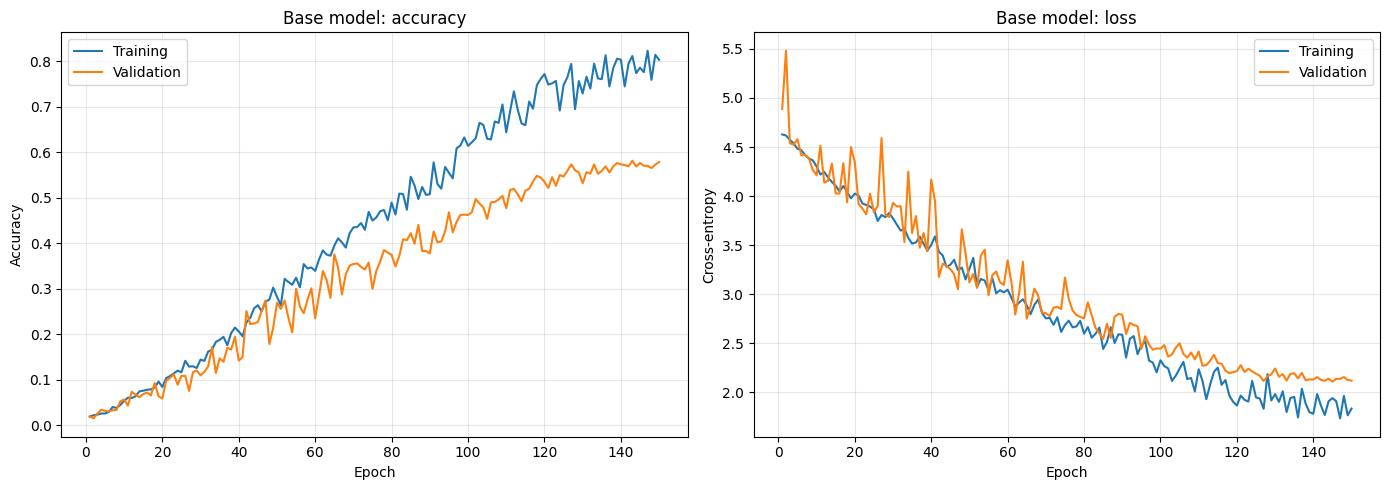

In [7]:
def plot_results(
    history1,
    history2,
    label1,
    label2,
    title,
    phase1="val",
    phase2="val",
):
    epochs1 = np.arange(1, len(history1[f"{phase1}_acc"]) + 1)
    epochs2 = np.arange(1, len(history2[f"{phase2}_acc"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    metrics = (
        ("acc", "accuracy", "Accuracy"),
        ("loss", "loss", "Cross-entropy"),
    )

    for axis, (metric, subtitle, ylabel) in zip(axes, metrics):
        axis.plot(
            epochs1,
            history1[f"{phase1}_{metric}"],
            label=label1,
        )
        axis.plot(
            epochs2,
            history2[f"{phase2}_{metric}"],
            label=label2,
        )

        axis.set(
            title=f"{title}: {subtitle}",
            xlabel="Epoch",
            ylabel=ylabel,
        )
        axis.grid(alpha=0.3)
        axis.legend()

    plt.tight_layout()
    plt.show()


plot_results(
    hist_custom_best,
    hist_custom_best,
    label1="Training",
    label2="Validation",
    title="Base model",
    phase1="train",
    phase2="val",
)

### Observations

Some overfitting can be observed and this is probably due to the fact that the official training split contains approximately 3,300 images distributed across 100 aircraft variants, corresponding to only about 33 images per class. At the same time, the residual network has enough capacity to learn highly specific details from these few examples. Consequently, the model can fit the training data more effectively than it generalizes to unseen validation images. This appears as a gap between training and validation performance. However, the presence of a generalization gap does not by itself imply that the model should be changed, since the main objective is to maximize validation performance. In particular, a model with higher training accuracy and higher validation accuracy is preferable to a model with a smaller gap but worse validation performance.

### Test set evaluation

In [8]:
test_results = evaluate_classifier(model_custom_best, test_loader, criterion, num_classes)
print(f"Test loss: {test_results['loss']:.4f}")
print(f"Test top-1 acc: {test_results['top1']:.4f}")
print(f"Test top-5 acc: {test_results['top5']:.4f}")

Test loss: 2.0728
Test top-1 acc: 0.6004
Test top-5 acc: 0.8806


### Ablation 1: removing Batch Normalization

This controlled ablation evaluates the contribution of Batch Normalization by setting `use_batchnorm=False`. All Batch Normalization layers are replaced
with `nn.Identity`, while convolutional biases are enabled.

The others experimental conditions are unchanged.

In [9]:
if RUN_STAGE == 1:
    # ablation: remove BatchNorm only.
    fix_randomness(SEED)
    ablation_loaders = make_train_val_loaders(SEED)

    model_custom_no_bn = CustomNet(
        num_classes=num_classes,
        max_drop_prob=MAX_DROP_PROB,
        use_batchnorm=False,
    ).to(device)

    optimizer_no_bn = optim.SGD(
        model_custom_no_bn.parameters(),
        lr=0.1,
        momentum=0.9,
        weight_decay=WEIGHT_DECAY,
    )

    warmup_scheduler_no_bn = optim.lr_scheduler.LinearLR(
        optimizer_no_bn, start_factor=0.1, total_iters=WARMUP_EPOCHS
    )
    cosine_scheduler_no_bn = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_no_bn, T_max=PART1_EPOCHS - WARMUP_EPOCHS, eta_min=1e-4
    )
    scheduler_no_bn = optim.lr_scheduler.SequentialLR(
        optimizer_no_bn,
        schedulers=[warmup_scheduler_no_bn, cosine_scheduler_no_bn],
        milestones=[WARMUP_EPOCHS],
    )

    print("Training controlled ablation without BatchNorm...")
    model_custom_no_bn, hist_custom_no_bn, fit_custom_no_bn = train_model(
        model_custom_no_bn,
        ablation_loaders,
        criterion,
        optimizer_no_bn,
        scheduler=scheduler_no_bn,
        num_epochs=PART1_EPOCHS,
        mixup_alpha=MIXUP_ALPHA,
    )
elif RUN_STAGE == 3:
    replay_history('BatchNorm ablation', hist_custom_no_bn)


Epoch 01/150 | train loss 4.6078, acc 0.0070 | val loss 4.6057, acc 0.0108 | lr 2.80e-02
Epoch 02/150 | train loss 4.6089, acc 0.0099 | val loss 4.6051, acc 0.0099 | lr 4.60e-02
Epoch 03/150 | train loss 4.6083, acc 0.0077 | val loss 4.6040, acc 0.0096 | lr 6.40e-02
Epoch 04/150 | train loss 4.6081, acc 0.0121 | val loss 4.6000, acc 0.0144 | lr 8.20e-02
Epoch 05/150 | train loss 4.6028, acc 0.0128 | val loss 4.5959, acc 0.0108 | lr 1.00e-01
Epoch 06/150 | train loss 4.5915, acc 0.0131 | val loss 4.5792, acc 0.0138 | lr 1.00e-01
Epoch 07/150 | train loss 4.5814, acc 0.0167 | val loss 4.5889, acc 0.0168 | lr 1.00e-01
Epoch 08/150 | train loss 4.5649, acc 0.0186 | val loss 4.5649, acc 0.0153 | lr 9.99e-02
Epoch 09/150 | train loss 4.5557, acc 0.0165 | val loss 4.5368, acc 0.0210 | lr 9.98e-02
Epoch 10/150 | train loss 4.5461, acc 0.0191 | val loss 4.5562, acc 0.0180 | lr 9.97e-02
Epoch 11/150 | train loss 4.5408, acc 0.0184 | val loss 4.5247, acc 0.0210 | lr 9.96e-02
Epoch 12/150 | train 

### BatchNorm ablation: validation accuracy and loss results

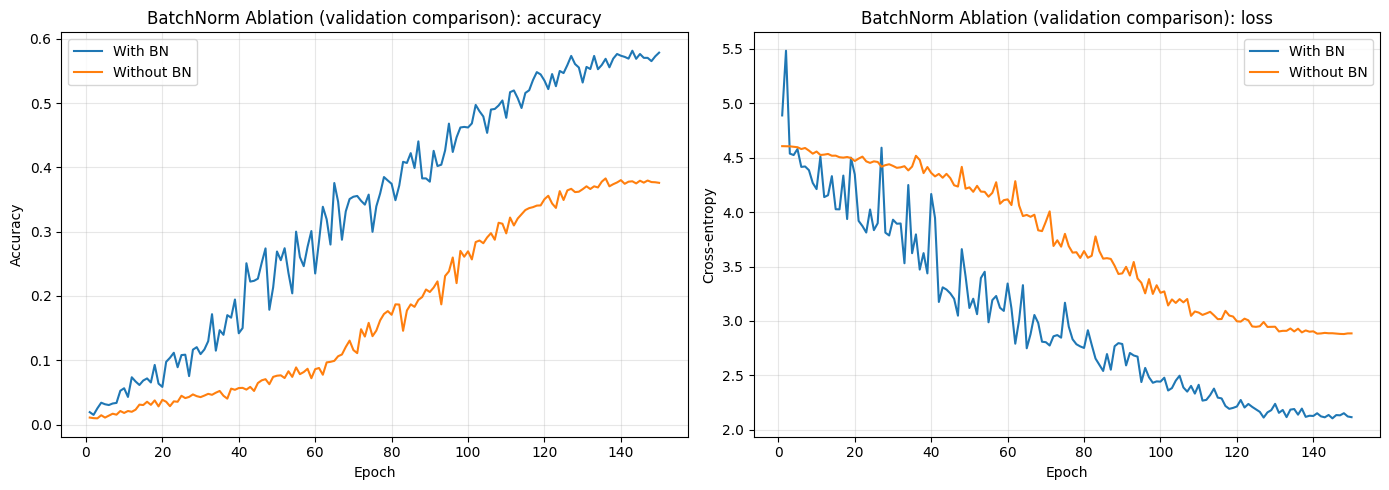

Best validation accuracy | with BN: 0.5815 | without BN: 0.3828


In [10]:
plot_results(
    hist_custom_best,
    hist_custom_no_bn,
    label1="With BN",
    label2="Without BN",
    title="BatchNorm Ablation (validation comparison)"
)

print( "Best validation accuracy | "f"with BN: {fit_custom_best['best_val_acc']:.4f} | "f"without BN: {fit_custom_no_bn['best_val_acc']:.4f}")

Removing Batch Normalization caused a substantial performance reduction. Since architecture, optimizer, scheduler, augmentation, epoch budget, and
random seed were otherwise preserved, the observed degradation provides experimental evidence that Batch Normalization makes a positive contribution
to the final design.

### Stage 1 hand-off for Kaggle checkpoint

The next cell saves the completed main model and BatchNorm ablation. Later stages load these results instead of repeating the two training runs.


In [11]:
if RUN_STAGE == 1:
    stage1_checkpoint = {
        "checkpoint_type": "stage1_main_bn",
        "part1_constants": {
            "PART1_EPOCHS": PART1_EPOCHS,
            "WARMUP_EPOCHS": WARMUP_EPOCHS,
            "MIXUP_ALPHA": MIXUP_ALPHA,
            "WEIGHT_DECAY": WEIGHT_DECAY,
            "MAX_DROP_PROB": MAX_DROP_PROB,
        },
        "models": {
            "model_custom_best": cpu_state_dict(model_custom_best),
            "model_custom_no_bn": cpu_state_dict(model_custom_no_bn),
        },
        "histories": {
            "hist_custom_best": hist_custom_best,
            "hist_custom_no_bn": hist_custom_no_bn,
        },
        "fit_info": {
            "fit_custom_best": fit_custom_best,
            "fit_custom_no_bn": fit_custom_no_bn,
        },
    }
    temporary_path = STAGE1_OUTPUT_PATH.with_suffix(".pt.tmp")
    torch.save(stage1_checkpoint, temporary_path)
    os.replace(temporary_path, STAGE1_OUTPUT_PATH)
    print(f"Stage 1 checkpoint saved to {STAGE1_OUTPUT_PATH}")
    print("Stage 1 complete; later experiment cells are intentionally skipped.")


### Ablation 2: removing residual connections

This ablation evaluates the contribution of residual connections
by setting `use_skip=False`. The shortcut additions are removed, so each
block uses only its main convolutional path.

Stochastic depth is disabled by setting `max_drop_prob=0.0`, because it
requires a shortcut to preserve information when the residual path is
dropped.

The other experimental conditions are unchanged.

In [12]:
if RUN_STAGE == 2:
    # ablation: remove residual (skip) connections only.
    fix_randomness(SEED)
    skip_ablation_loaders = make_train_val_loaders(SEED)

    model_custom_no_skip = CustomNet(
        num_classes=num_classes,
        max_drop_prob=0.0,   # stochastic depth is not meaningful without a skip connection
        use_batchnorm=True,
        use_skip=False,
    ).to(device)
    print(f"Trainable parameters (no skip): "
          f"{sum(p.numel() for p in model_custom_no_skip.parameters() if p.requires_grad):,}")

    optimizer_no_skip = optim.SGD(
        model_custom_no_skip.parameters(),
        lr=0.1,
        momentum=0.9,
        weight_decay=WEIGHT_DECAY,
    )

    warmup_scheduler_no_skip = optim.lr_scheduler.LinearLR(
        optimizer_no_skip, start_factor=0.1, total_iters=WARMUP_EPOCHS
    )
    cosine_scheduler_no_skip = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_no_skip, T_max=PART1_EPOCHS - WARMUP_EPOCHS, eta_min=1e-4
    )
    scheduler_no_skip = optim.lr_scheduler.SequentialLR(
        optimizer_no_skip,
        schedulers=[warmup_scheduler_no_skip, cosine_scheduler_no_skip],
        milestones=[WARMUP_EPOCHS],
    )

    print("Training controlled ablation without residual connections...")
    model_custom_no_skip, hist_custom_no_skip, fit_custom_no_skip = train_model(
        model_custom_no_skip,
        skip_ablation_loaders,
        criterion,
        optimizer_no_skip,
        scheduler=scheduler_no_skip,
        num_epochs=PART1_EPOCHS,
        mixup_alpha=MIXUP_ALPHA,
    )
elif RUN_STAGE == 3:
    replay_history('Residual-connection ablation', hist_custom_no_skip)


Epoch 01/150 | train loss 4.6037, acc 0.0137 | val loss 4.6682, acc 0.0183 | lr 2.80e-02
Epoch 02/150 | train loss 4.5709, acc 0.0206 | val loss 4.5423, acc 0.0294 | lr 4.60e-02
Epoch 03/150 | train loss 4.5683, acc 0.0219 | val loss 5.0637, acc 0.0216 | lr 6.40e-02
Epoch 04/150 | train loss 4.5489, acc 0.0233 | val loss 4.5472, acc 0.0267 | lr 8.20e-02
Epoch 05/150 | train loss 4.5169, acc 0.0259 | val loss 4.6359, acc 0.0240 | lr 1.00e-01
Epoch 06/150 | train loss 4.5175, acc 0.0276 | val loss 4.6216, acc 0.0204 | lr 1.00e-01
Epoch 07/150 | train loss 4.4756, acc 0.0325 | val loss 4.5541, acc 0.0243 | lr 1.00e-01
Epoch 08/150 | train loss 4.4509, acc 0.0258 | val loss 4.3905, acc 0.0390 | lr 9.99e-02
Epoch 09/150 | train loss 4.4010, acc 0.0373 | val loss 4.3316, acc 0.0444 | lr 9.98e-02
Epoch 10/150 | train loss 4.3813, acc 0.0421 | val loss 4.4246, acc 0.0360 | lr 9.97e-02
Epoch 11/150 | train loss 4.3464, acc 0.0387 | val loss 4.4517, acc 0.0288 | lr 9.96e-02
Epoch 12/150 | train 

### Residual connections ablation: validation accuracy and loss results

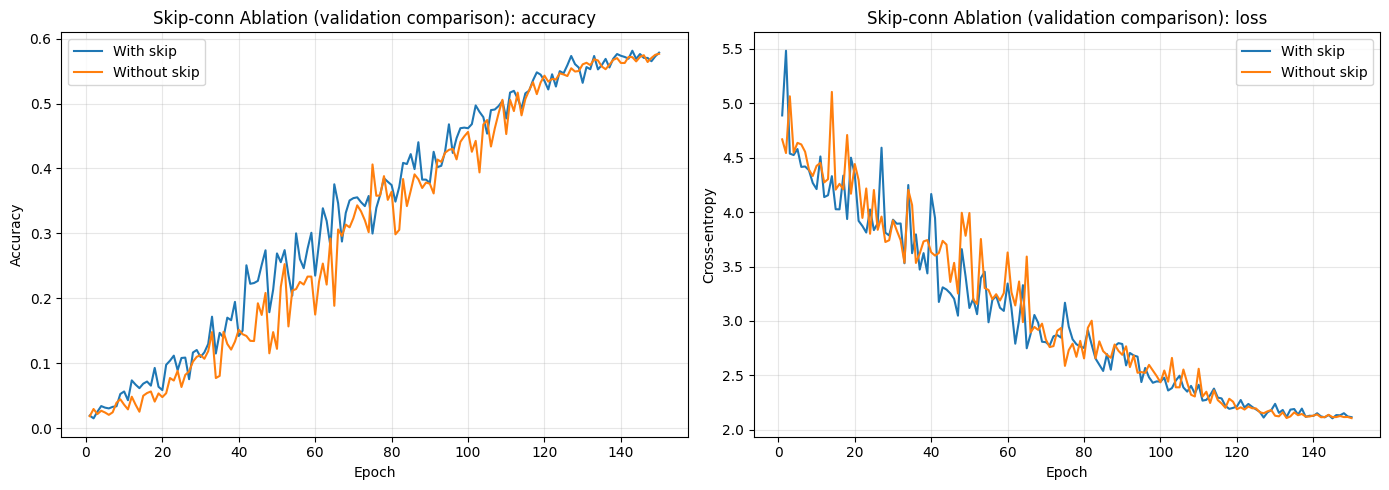

Best validation accuracy | with skip connections: 0.5815 | without skip connections: 0.5767


In [13]:
if RUN_STAGE in {2, 3}:
    plot_results(
        hist_custom_best,
        hist_custom_no_skip,
        label1="With skip",
        label2="Without skip",
        title="Skip-conn Ablation (validation comparison)"
    )

    print("Best validation accuracy | "f"with skip connections: {fit_custom_best['best_val_acc']:.4f} | "f"without skip connections: {fit_custom_no_skip['best_val_acc']:.4f}")

This result is very close to the validation accuracy obtained by the complete custom model. Therefore, this experiment does not provide clear evidence
that residual connections improved final classification accuracy in this specific architecture.

A likely explanation is that the network contains only eight blocks and is not deep enough to suffer severely from the optimization degradation that
residual connections are primarily designed to address. 

Residual connections remain theoretically motivated and may improve optimization robustness, but their positive impact on validation accuracy is not demonstrated by this experiment.

However, we decided to leave the residual connections in the custom model because (even if it could be due to some noise) in every experiment we tried the residual connection model has a bit higher validation accuracy.

### Ablation 3: removing Mixup

This ablation evaluates the contribution of Mixup by setting `mixup_alpha=0.0`. Training images are therefore processed individually
without blending their pixels or labels. Everything else remains unchanged.

In [14]:
if RUN_STAGE == 2:
    # Controlled ablation: remove mixup only.
    fix_randomness(SEED)
    mixup_ablation_loaders = make_train_val_loaders(SEED)

    model_custom_no_mixup = CustomNet(
        num_classes=num_classes,
        max_drop_prob=MAX_DROP_PROB,
        use_batchnorm=True,
        use_skip=True,
    ).to(device)
    print(f"Trainable parameters (no mixup): "
          f"{sum(p.numel() for p in model_custom_no_mixup.parameters() if p.requires_grad):,}")

    optimizer_no_mixup = optim.SGD(
        model_custom_no_mixup.parameters(),
        lr=0.1,
        momentum=0.9,
        weight_decay=WEIGHT_DECAY,
    )

    warmup_scheduler_no_mixup = optim.lr_scheduler.LinearLR(
        optimizer_no_mixup, start_factor=0.1, total_iters=WARMUP_EPOCHS
    )
    cosine_scheduler_no_mixup = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_no_mixup, T_max=PART1_EPOCHS - WARMUP_EPOCHS, eta_min=1e-4
    )
    scheduler_no_mixup = optim.lr_scheduler.SequentialLR(
        optimizer_no_mixup,
        schedulers=[warmup_scheduler_no_mixup, cosine_scheduler_no_mixup],
        milestones=[WARMUP_EPOCHS],
    )

    print("Training controlled ablation without mixup...")
    model_custom_no_mixup, hist_custom_no_mixup, fit_custom_no_mixup = train_model(
        model_custom_no_mixup,
        mixup_ablation_loaders,
        criterion,
        optimizer_no_mixup,
        scheduler=scheduler_no_mixup,
        num_epochs=PART1_EPOCHS,
        mixup_alpha=0.0,
    )
elif RUN_STAGE == 3:
    replay_history('Mixup ablation', hist_custom_no_mixup)


Epoch 01/150 | train loss 4.6182, acc 0.0165 | val loss 4.6157, acc 0.0264 | lr 2.80e-02
Epoch 02/150 | train loss 4.5845, acc 0.0234 | val loss 4.6401, acc 0.0300 | lr 4.60e-02
Epoch 03/150 | train loss 4.5142, acc 0.0333 | val loss 9.2035, acc 0.0171 | lr 6.40e-02
Epoch 04/150 | train loss 4.4863, acc 0.0267 | val loss 4.4379, acc 0.0399 | lr 8.20e-02
Epoch 05/150 | train loss 4.4158, acc 0.0348 | val loss 4.4234, acc 0.0465 | lr 1.00e-01
Epoch 06/150 | train loss 4.3833, acc 0.0393 | val loss 5.1294, acc 0.0273 | lr 1.00e-01
Epoch 07/150 | train loss 4.3608, acc 0.0450 | val loss 4.6694, acc 0.0219 | lr 1.00e-01
Epoch 08/150 | train loss 4.3094, acc 0.0459 | val loss 4.8995, acc 0.0291 | lr 9.99e-02
Epoch 09/150 | train loss 4.2703, acc 0.0465 | val loss 4.3065, acc 0.0474 | lr 9.98e-02
Epoch 10/150 | train loss 4.2132, acc 0.0603 | val loss 4.2905, acc 0.0525 | lr 9.97e-02
Epoch 11/150 | train loss 4.1615, acc 0.0651 | val loss 4.2923, acc 0.0570 | lr 9.96e-02
Epoch 12/150 | train 

### Mixup ablation: validation accuracy and loss results

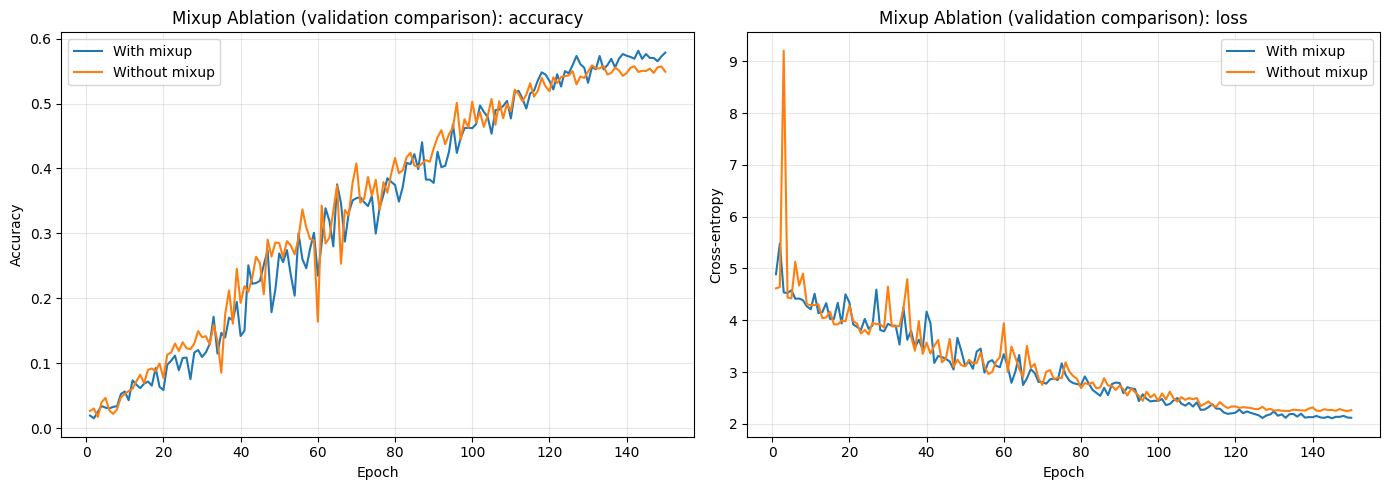

Best validation accuracy | with mixup: 0.5815 | without mixup: 0.5590


In [15]:
if RUN_STAGE in {2, 3}:  
    plot_results(
        hist_custom_best,
        hist_custom_no_mixup,
        label1="With mixup",
        label2="Without mixup",
        title="Mixup Ablation (validation comparison)"
    )

    print("Best validation accuracy | "f"with mixup: {fit_custom_best['best_val_acc']:.4f} | "f"without mixup: {fit_custom_no_mixup['best_val_acc']:.4f}")

These results support Mixup as an effective regularizer. In fact, it prevents the network from becoming excessively
confident about individual training examples and encourages smoother class
decision boundaries. The resulting reduction in training fit is compensated
by better validation performance.

### Ablation 4: removing Label Smoothing

This ablation evaluates the contribution of label smoothing by setting
`label_smoothing=0.0` instead of `0.1`. 

The experiment tests whether label smoothing provides an additional
generalization benefit when Mixup already softens the training targets.

In [16]:
if RUN_STAGE == 2:
    fix_randomness(SEED)
    no_ls_loaders = make_train_val_loaders(SEED)

    model_custom_no_ls = CustomNet(
        num_classes=num_classes,
        max_drop_prob=MAX_DROP_PROB,
        use_batchnorm=True,
        use_skip=True,
    ).to(device)

    criterion_no_ls = nn.CrossEntropyLoss(label_smoothing=0.0) # no label smoothing

    optimizer_no_ls = optim.SGD(
        model_custom_no_ls.parameters(),
        lr=0.1,
        momentum=0.9,
        weight_decay=WEIGHT_DECAY,
    )

    # Same five-epoch warm-up and cosine decay as Part 1.
    warmup_no_ls = optim.lr_scheduler.LinearLR(
        optimizer_no_ls,
        start_factor=0.1,
        total_iters=5,
    )
    cosine_no_ls = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_no_ls,
        T_max=PART1_EPOCHS - 5,
        eta_min=1e-4,
    )
    scheduler_no_ls = optim.lr_scheduler.SequentialLR(
        optimizer_no_ls,
        schedulers=[warmup_no_ls, cosine_no_ls],
        milestones=[5],
    )

    print("Training ablation without label smoothing...")

    model_custom_no_ls, hist_custom_no_ls, fit_custom_no_ls = train_model(
        model_custom_no_ls,
        no_ls_loaders,
        criterion_no_ls,
        optimizer_no_ls,
        scheduler=scheduler_no_ls,
        num_epochs=PART1_EPOCHS,
        mixup_alpha=MIXUP_ALPHA,
    )

elif RUN_STAGE == 3:
    replay_history("Label-smoothing ablation", hist_custom_no_ls)

Epoch 01/150 | train loss 4.6259, acc 0.0184 | val loss 4.7780, acc 0.0252 | lr 2.80e-02
Epoch 02/150 | train loss 4.6015, acc 0.0204 | val loss 4.5517, acc 0.0300 | lr 4.60e-02
Epoch 03/150 | train loss 4.5562, acc 0.0232 | val loss 4.5116, acc 0.0264 | lr 6.40e-02
Epoch 04/150 | train loss 4.5365, acc 0.0208 | val loss 4.4477, acc 0.0360 | lr 8.20e-02
Epoch 05/150 | train loss 4.4776, acc 0.0276 | val loss 4.4133, acc 0.0363 | lr 1.00e-01
Epoch 06/150 | train loss 4.4523, acc 0.0346 | val loss 4.3796, acc 0.0369 | lr 1.00e-01
Epoch 07/150 | train loss 4.3919, acc 0.0354 | val loss 4.4488, acc 0.0345 | lr 1.00e-01
Epoch 08/150 | train loss 4.3499, acc 0.0397 | val loss 4.5644, acc 0.0264 | lr 9.99e-02
Epoch 09/150 | train loss 4.3349, acc 0.0354 | val loss 4.3398, acc 0.0438 | lr 9.98e-02
Epoch 10/150 | train loss 4.2715, acc 0.0493 | val loss 4.3008, acc 0.0354 | lr 9.97e-02
Epoch 11/150 | train loss 4.2235, acc 0.0494 | val loss 4.2655, acc 0.0489 | lr 9.96e-02
Epoch 12/150 | train 

### Label-smoothing ablation: validation accuracy and loss results

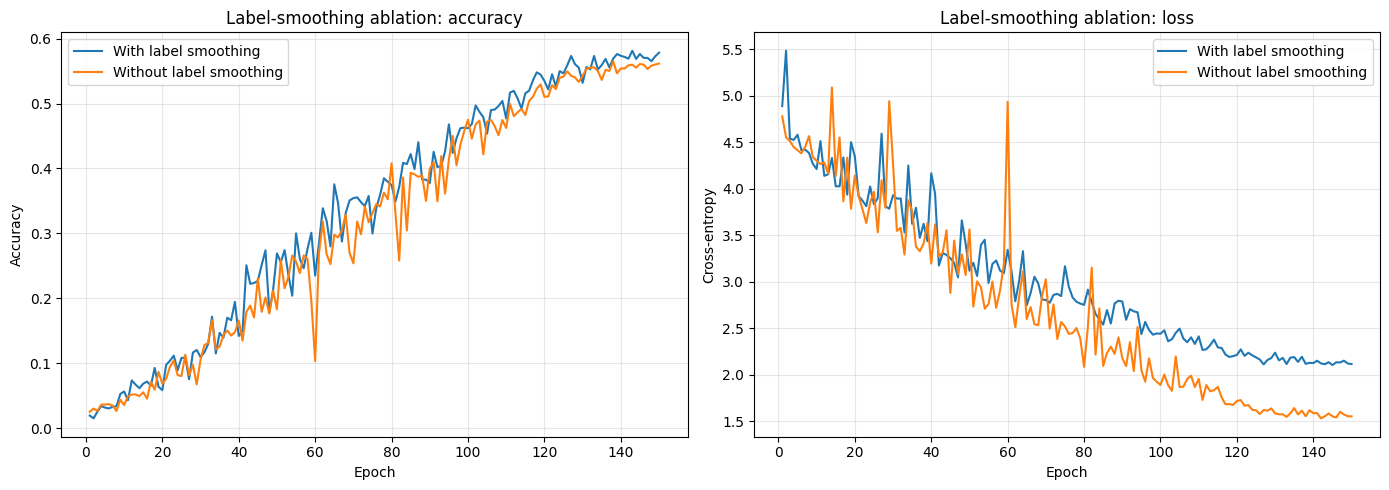

Best validation accuracy | with label smoothing: 0.5815 | without label smoothing: 0.5650


In [17]:
if RUN_STAGE in {2, 3}:
    plot_results(
        hist_custom_best,
        hist_custom_no_ls,
        label1="With label smoothing",
        label2="Without label smoothing",
        title="Label-smoothing ablation",
        phase1="val",
        phase2="val",
    )

    print(f"Best validation accuracy | with label smoothing: {fit_custom_best['best_val_acc']:.4f} | without label smoothing: {fit_custom_no_ls['best_val_acc']:.4f}")

The model with label smoothing finishes at approximately 58% validation accuracy, compared with about 56% without smoothing. 
This result suggests that label smoothing provides a modest additional generalization benefit.

Furthermore, the model without label smoothing achieves a lower numerical validation loss, but this does not imply better classification performance.

In fact, validation accuracy is directly comparable because both models are evaluated on the same validation images using standard Top-1 accuracy, while the absolute validation losses are not directly comparable: the baseline uses cross-entropy with label smoothing, whereas the ablated model uses cross-entropy without smoothing. These criteria assign different target distributions and can produce different losses even for identical predictions.

Therefore, validation accuracy is the primary comparison metric. Each loss curve is used to assess progress within its own experiment and therefore a lower loss across the two experiments does not necessarily indicate
better performance.

### Experiment: testing a different learning-rate schedule

This experiment (not a real ablation) evaluates the cosine-decay schedule by replacing it with `ReduceLROnPlateau`. The model, optimizer, initial five-epoch warm-up, augmentation, Mixup, and all other training settings remain unchanged.

This comparison tests whether the fixed cosine schedule or a validation-driven schedule provides better optimization and generalization.

In [18]:
if RUN_STAGE == 2:
    # same warm-up, then ReduceLROnPlateau instead of cosine annealing for the remainder of training.
    fix_randomness(SEED)
    plateau_exp_loaders = make_train_val_loaders(SEED)

    model_custom_plateau = CustomNet(
        num_classes=num_classes,
        max_drop_prob=MAX_DROP_PROB,
        use_batchnorm=True,
        use_skip=True,
    ).to(device)
    print(f"Trainable parameters (plateau schedule): "
          f"{sum(p.numel() for p in model_custom_plateau.parameters() if p.requires_grad):,}")

    optimizer_plateau = optim.SGD(
        model_custom_plateau.parameters(),
        lr=0.1,
        momentum=0.9,
        weight_decay=WEIGHT_DECAY,
    )

    # identical linear warm-up as before
    warmup_scheduler_plateau = optim.lr_scheduler.LinearLR(
        optimizer_plateau, start_factor=0.1, total_iters=WARMUP_EPOCHS
    )

    print(f"Plateau-schedule experiment (1): {WARMUP_EPOCHS}-epoch warm-up...")
    model_custom_plateau, hist_plateau_warmup, fit_plateau_warmup = train_model(
        model_custom_plateau,
        plateau_exp_loaders,
        criterion,
        optimizer_plateau,
        scheduler=warmup_scheduler_plateau,
        num_epochs=WARMUP_EPOCHS,
        mixup_alpha=MIXUP_ALPHA,
    )

    # ReduceLROnPlateau for the remaining epochs 
    PLATEAU_FACTOR = 0.5
    PLATEAU_PATIENCE = 5
    PLATEAU_THRESHOLD = 1e-2   # relative; avoids resetting patience on marginal "new bests"
    PLATEAU_MIN_LR = 1e-5      # avoids decaying into a range where updates are negligible

    scheduler_plateau = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_plateau,
        mode="min",
        factor=PLATEAU_FACTOR,
        patience=PLATEAU_PATIENCE,
        threshold=PLATEAU_THRESHOLD,
        threshold_mode="rel",
        min_lr=PLATEAU_MIN_LR,
    )

    print(f"Plateau-schedule experiment (2): {PART1_EPOCHS - WARMUP_EPOCHS} epochs of ReduceLROnPlateau...")
    model_custom_plateau, hist_plateau_decay, fit_plateau_decay = train_model(
        model_custom_plateau,
        plateau_exp_loaders,
        criterion,
        optimizer_plateau,
        scheduler=scheduler_plateau,
        num_epochs=PART1_EPOCHS - WARMUP_EPOCHS,
        mixup_alpha=MIXUP_ALPHA,
    )

    hist_custom_plateau = combine_histories(hist_plateau_warmup, hist_plateau_decay)
    fit_custom_plateau = {
        "best_val_acc": max(fit_plateau_warmup["best_val_acc"], fit_plateau_decay["best_val_acc"]),
        "best_val_loss": min(fit_plateau_warmup["best_val_loss"], fit_plateau_decay["best_val_loss"]),
    }
elif RUN_STAGE == 3:
    replay_history('Learning-rate schedule ablation', hist_custom_plateau)


Epoch 01/150 | train loss 4.6257, acc 0.0169 | val loss 4.6330, acc 0.0285 | lr 2.80e-02
Epoch 02/150 | train loss 4.5970, acc 0.0265 | val loss 4.7273, acc 0.0201 | lr 4.60e-02
Epoch 03/150 | train loss 4.5756, acc 0.0221 | val loss 5.0771, acc 0.0171 | lr 6.40e-02
Epoch 04/150 | train loss 4.5480, acc 0.0232 | val loss 4.5585, acc 0.0291 | lr 8.20e-02
Epoch 05/150 | train loss 4.5028, acc 0.0291 | val loss 4.4842, acc 0.0285 | lr 1.00e-01
Epoch 06/150 | train loss 4.5362, acc 0.0251 | val loss 4.5164, acc 0.0258 | lr 1.00e-01
Epoch 07/150 | train loss 4.5051, acc 0.0278 | val loss 4.4093, acc 0.0405 | lr 1.00e-01
Epoch 08/150 | train loss 4.4371, acc 0.0357 | val loss 4.4671, acc 0.0309 | lr 1.00e-01
Epoch 09/150 | train loss 4.4125, acc 0.0326 | val loss 4.4307, acc 0.0471 | lr 1.00e-01
Epoch 10/150 | train loss 4.3691, acc 0.0442 | val loss 4.3262, acc 0.0441 | lr 1.00e-01
Epoch 11/150 | train loss 4.3266, acc 0.0469 | val loss 4.4079, acc 0.0411 | lr 1.00e-01
Epoch 12/150 | train 

### Learning rate experiment: validation accuracy and loss results

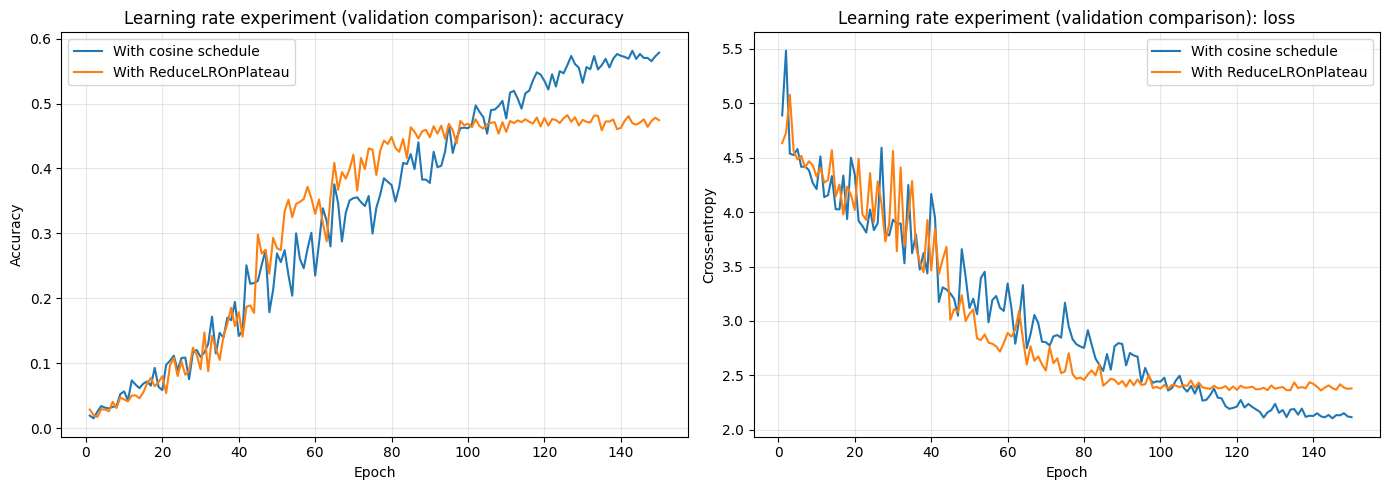

Best validation accuracy | cosine schedule: 0.5815 | ReduceLROnPlateau: 0.4821


In [19]:
if RUN_STAGE in {2, 3}:    
    plot_results(
        hist_custom_best,
        hist_custom_plateau,
        label1="With cosine schedule",
        label2="With ReduceLROnPlateau",
        title="Learning rate experiment (validation comparison)"
    )

    print("Best validation accuracy | "f"cosine schedule: {fit_custom_best['best_val_acc']:.4f} | "f"ReduceLROnPlateau: {fit_custom_plateau['best_val_acc']:.4f}")

`ReduceLROnPlateau` initially improves validation accuracy faster than cosine decay. 
However, the `ReduceLROnPlateau` curve begins to plateau around epoch 90.
Its validation accuracy remains close to 47-48%, and its validation loss stabilizes around 2.4. This suggests that the scheduler reduced the learning
rate before the model had reached its best representation and subsequently provided updates that were too small to escape the plateau.

The cosine schedule improves more gradually but continues making progress throughout the later training epochs. It overtakes `ReduceLROnPlateau` at
approximately epoch 100 and finishes near 57-58% validation accuracy, about 10 percentage points higher. Its validation loss also continues decreasing
to approximately 2.1 instead of reaching an early plateau.

These results support cosine decay as the better schedule for the final model.

### Ablations' summary

| Configuration | Change from baseline | Validation Top-1 | Difference from baseline |
|---|---|---:|---:|
| **Full CustomNet** | None | **58.15%** | — |
| Without Batch Normalization | Remove BN; enable convolutional biases | 38.28% | −19.87 % |
| Without residual connections | Remove skip additions and disable stochastic depth | 57.67% | −0.48 % |
| Without Mixup | Set Mixup alpha to zero | 55.90% | −2.25 % |
| Without label smoothing | Set label smoothing to zero | 56.50% | −1.65 % |
| Alternative LR schedule | Replace cosine decay with ReduceLROnPlateau after warm-up | 48.21% | −9.94 % |


### Stage 2 hand-off

The next cell writes a self-contained checkpoint with all five Part 1 experiments. Stage 3 needs only this Stage 2 output.


In [20]:
if RUN_STAGE == 2:
    stage2_checkpoint = {
        "checkpoint_type": "stage2_complete_part1",
        "part1_constants": {
            "PART1_EPOCHS": PART1_EPOCHS,
            "WARMUP_EPOCHS": WARMUP_EPOCHS,
            "MIXUP_ALPHA": MIXUP_ALPHA,
            "WEIGHT_DECAY": WEIGHT_DECAY,
            "MAX_DROP_PROB": MAX_DROP_PROB,
        },
        "models": {
            "model_custom_best": cpu_state_dict(model_custom_best),
            "model_custom_no_bn": cpu_state_dict(model_custom_no_bn),
            "model_custom_no_skip": cpu_state_dict(model_custom_no_skip),
            "model_custom_plateau": cpu_state_dict(model_custom_plateau),
            "model_custom_no_mixup": cpu_state_dict(model_custom_no_mixup),
            "model_custom_no_ls": cpu_state_dict(model_custom_no_ls),
        },
        "histories": {
            "hist_custom_best": hist_custom_best,
            "hist_custom_no_bn": hist_custom_no_bn,
            "hist_custom_no_skip": hist_custom_no_skip,
            "hist_plateau_warmup": hist_plateau_warmup,
            "hist_plateau_decay": hist_plateau_decay,
            "hist_custom_plateau": hist_custom_plateau,
            "hist_custom_no_mixup": hist_custom_no_mixup,
            "hist_custom_no_ls": hist_custom_no_ls,
        },
        "fit_info": {
            "fit_custom_best": fit_custom_best,
            "fit_custom_no_bn": fit_custom_no_bn,
            "fit_custom_no_skip": fit_custom_no_skip,
            "fit_plateau_warmup": fit_plateau_warmup,
            "fit_plateau_decay": fit_plateau_decay,
            "fit_custom_plateau": fit_custom_plateau,
            "fit_custom_no_mixup": fit_custom_no_mixup,
            "fit_custom_no_ls": fit_custom_no_ls,
        },
    }
    temporary_path = STAGE2_OUTPUT_PATH.with_suffix(".pt.tmp")
    torch.save(stage2_checkpoint, temporary_path)
    os.replace(temporary_path, STAGE2_OUTPUT_PATH)
    print(f"Stage 2 checkpoint saved to {STAGE2_OUTPUT_PATH}")
    print("Stage 2 complete; Part 2 cells are intentionally skipped.")


## Part 2: Fine-tune ResNet-18

## Part 2: fine-tune an existing network

Your goal is to fine-tune a pretrained ResNet-18 model on `FGVCAircraft`. Use the implementation provided by PyTorch, i.e. the opposite of part 1. Specifically, use the PyTorch ResNet-18 model pretrained on ImageNet-1K (V1). Divide your fine-tuning into two parts:

2A. First, fine-tune the ResNet-18 with the same training hyperparameters you used for your best model in part 1.

2B. Then, tweak the training hyperparameters to increase the accuracy on the test split. Justify your choices by analyzing the training plots and/or citing sources that guided you in your decisions — papers, blog posts, YouTube videos, or whatever else you may find useful. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~70%.

## Part 2A
ResNet-18 pretrained on ImageNet-1K V1 is here fine-tuned using the same training hyperparameters as the best custom model from Part 1. However, these settings may not be optimal for a pretrained network. 

In [21]:
if RUN_STAGE == 3:

    PART2A_LR = 0.1
    PART2A_WEIGHT_DECAY = 5e-4
    PART2A_MOMENTUM = 0.9
    PART2A_WARMUP_EPOCHS = 5
    PART2A_MIXUP_ALPHA = 0.2
    PART2A_ETA_MIN = 1e-4

    fix_randomness(SEED)

    # same batch size, augmentations and shuffle seed used in Part 1.
    part2a_loaders = make_train_val_loaders(SEED)

    # PyTorch ResNet-18 pretrained on ImageNet-1K V1
    model_rn_base = resnet18(
        weights=ResNet18_Weights.IMAGENET1K_V1
    )

    # replace the original 1000-class ImageNet classifier with a randomly initialized classifier for the 100 aircraft variants.
    model_rn_base.fc = nn.Linear(
        model_rn_base.fc.in_features,
        num_classes,
    )
    model_rn_base = model_rn_base.to(device)

    # same optimizer and optimizer hyperparameters as Part 1.
    optimizer_rn_base = optim.SGD(
        model_rn_base.parameters(),
        lr=PART2A_LR,
        momentum=PART2A_MOMENTUM,
        weight_decay=PART2A_WEIGHT_DECAY,
    )

    # same five-epoch linear warm-up used in Part 1.
    warmup_scheduler_rn = optim.lr_scheduler.LinearLR(
        optimizer_rn_base,
        start_factor=0.1,
        total_iters=PART2A_WARMUP_EPOCHS,
    )

    # same cosine schedule and minimum learning rate used in Part 1.
    cosine_scheduler_rn = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_rn_base,
        T_max=PART1_EPOCHS - PART2A_WARMUP_EPOCHS,
        eta_min=PART2A_ETA_MIN,
    )

    scheduler_rn_base = optim.lr_scheduler.SequentialLR(
        optimizer_rn_base,
        schedulers=[
            warmup_scheduler_rn,
            cosine_scheduler_rn,
        ],
        milestones=[PART2A_WARMUP_EPOCHS],
    )

    print("Part 2A: fine-tuning ImageNet-1K V1 ResNet-18 with the same training hyperparameters as Part 1...")

    model_rn_base, hist_rn_base, fit_rn_base = train_model(
        model=model_rn_base,
        dataloaders=part2a_loaders,
        criterion=criterion,
        optimizer=optimizer_rn_base,
        scheduler=scheduler_rn_base,
        num_epochs=PART1_EPOCHS,
        mixup_alpha=PART2A_MIXUP_ALPHA,
    )

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


Part 2A: fine-tuning ImageNet-1K V1 ResNet-18 with the same training hyperparameters as Part 1...


Epoch 01/150 | train loss 4.4981, acc 0.0438 | val loss 3.8693, acc 0.1215 | lr 2.80e-02


Epoch 02/150 | train loss 3.9452, acc 0.1498 | val loss 3.7905, acc 0.1809 | lr 4.60e-02


...

Epoch 146/150 | train loss 1.3905, acc 0.8823 | val loss 1.9084, acc 0.6850 | lr 2.87e-04


Epoch 147/150 | train loss 1.3358, acc 0.9008 | val loss 1.9125, acc 0.6883 | lr 2.05e-04


Epoch 148/150 | train loss 1.4114, acc 0.8737 | val loss 1.9132, acc 0.6859 | lr 1.47e-04


Epoch 149/150 | train loss 1.2683, acc 0.9125 | val loss 1.9058, acc 0.6820 | lr 1.12e-04


Epoch 150/150 | train loss 1.3395, acc 0.9077 | val loss 1.8943, acc 0.6853 | lr 1.00e-04
Best checkpoint: epoch 147, val acc 0.6883, val loss 1.9125 (122.4 min)


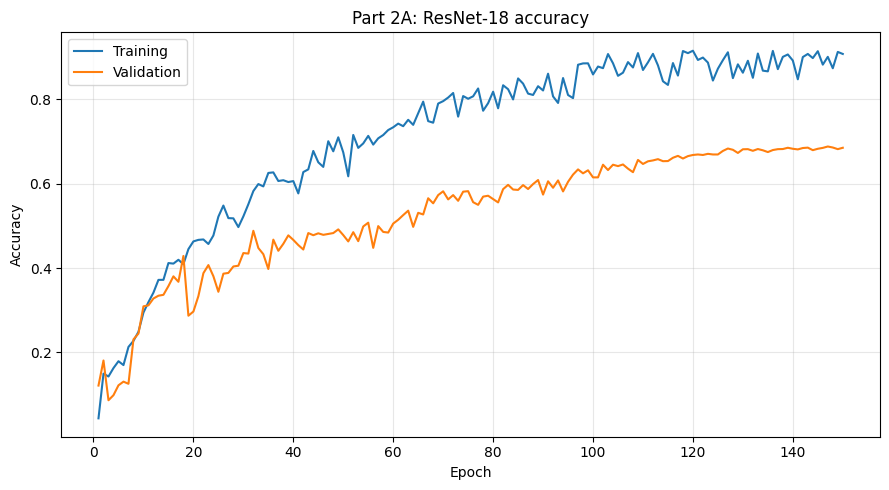

In [22]:
if RUN_STAGE == 3:
    epochs = range(1, len(hist_rn_base["train_acc"]) + 1)

    plt.figure(figsize=(9, 5))

    plt.plot(
        epochs,
        hist_rn_base["train_acc"],
        label="Training",
    )
    plt.plot(
        epochs,
        hist_rn_base["val_acc"],
        label="Validation",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Part 2A: ResNet-18 accuracy")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

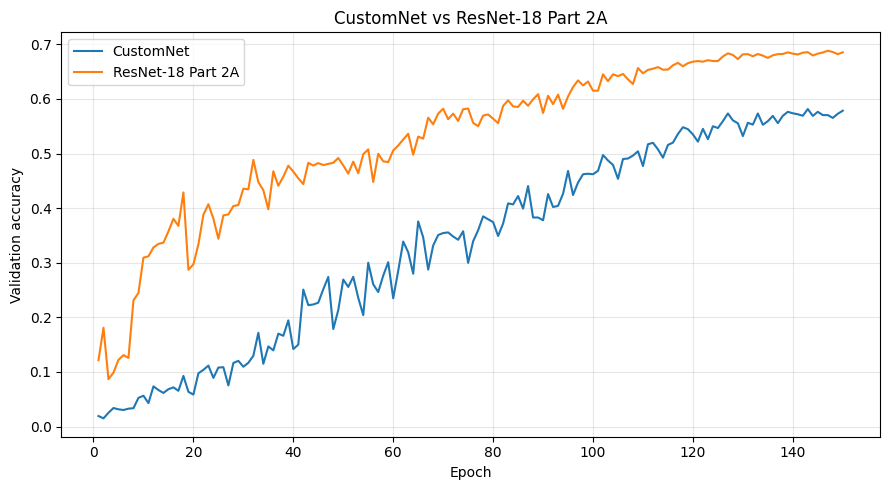

In [23]:
if RUN_STAGE == 3:
    plt.figure(figsize=(9, 5))

    plt.plot(
        range(1, len(hist_custom_best["val_acc"]) + 1),
        hist_custom_best["val_acc"],
        label="CustomNet",
    )
    plt.plot(
        range(1, len(hist_rn_base["val_acc"]) + 1),
        hist_rn_base["val_acc"],
        label="ResNet-18 Part 2A",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Validation accuracy")
    plt.title("CustomNet vs ResNet-18 Part 2A")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### Part 2A results

The ImageNet-pretrained ResNet-18 reached its best validation accuracy at epoch 147 ($a_{\mathrm{val}} = 68.83\%$).

This is a substantial improvement over the custom Part 1 network, which reached approximately 57-58% validation accuracy. The pretrained ResNet-18
therefore improves validation performance by approximately 11 percentage points, despite being trained with the same hyperparameters selected for the
custom model.

This result demonstrates the benefit of transfer learning. The custom model must learn all its visual representations from the FGVC-Aircraft training split, whereas ResNet-18 begins with features learned from ImageNet-1K. These pretrained features already represent general visual patterns such as edges, textures, shapes, and object components, which can then be adapted to aircraft variants.

During the final epochs, training accuracy remains around 88-91%, while validation accuracy remains around 68-69%. This indicates some overfitting, which is expected because the training split contains only about 33 images per aircraft class. However, the two accuracy values are not directly comparable: training accuracy is measured on mixed and augmented samples, whereas validation accuracy is standard Top-1 accuracy on unmodified images.

## Part 2B: transfer-learning-specific fine-tuning

In this part we introduce a strategy designed specifically for transfer learning.

A pretrained network already contains useful visual representations learned from a large dataset. However, these features should initially be protected while the new classifier adapts to the target task. The backbone should then be fine-tuned using a smaller learning rate than the classifier, reducing the risk of destroying useful pretrained features.

### Preprocessing

Part 2B uses the mean and standard deviation associated with the ImageNet-1K V1 weights. This matches the input distribution used to pretrain ResNet-18.

The input resolution is increased from 224 to 384 pixels to retain more of the small visual details that distinguish similar aircraft variants. The
bounding-box margin is also increased to 20% to preserve additional context around the aircrafts' details. In particular, images are resized using letterboxing, which means that the complete expanded aircraft region is scaled inside a square and padded where necessary.

Because the larger input requires more GPU memory, the batch size is reduced from 64 to 32.

Training augmentation is realized through random horizontal flipping and light colour jitter. Obviously, validation and test preprocessing remains deterministic.

### Classification head

The original ImageNet classifier is replaced with a new classifier for the 100 FGVC-Aircraft variants.

A dropout layer with probability 0.30 is placed before the final linear layer. This dropout layer acts as a regularizer, since it randomly sets part of the
activations to zero during training and this prevents the classifier from depending too strongly on a small set of features and can reduce overfitting.

### Classifier warm-up

The pretrained backbone is frozen for the first three epochs, and only the new classification head is trained.

The frozen backbone is also kept in evaluation mode so that its Batch Normalization statistics remain unchanged. This allows the randomly initialized classifier to begin learning the new classes without sending large and unstable updates through the pretrained feature extractor. In this way we want not to lose the already learned capacities of the network.
The classifier uses AdamW with a learning rate of `1e-3`. Mixup is disabled during this short warm-up stage.

### Full-network fine-tuning

After warm-up, all ResNet-18 parameters are unfrozen.

The classifier and backbone use different learning rates (classifier: `5e-4`; pretrained backbone: `5e-5`).
This follows the transfer-learning recommendation that suggests that generic pretrained features should be modified more cautiously than the newly initialized task-specific layer.
Fine-tuning runs for 40 epochs using cosine learning-rate decay down to
`1e-6`.

### Regularization

AdamW uses a weight decay of `5e-4` to discourage excessively large weights;
Mixup is enabled during full-network fine-tuning with $\alpha=0.2$; Label smoothing is here not used.

### Model selection

The best validation checkpoint is saved separately during classifier warm-up
and full-network fine-tuning.

At the end of training, the checkpoint with the higher validation accuracy is selected. If unfreezing the backbone reduces validation performance, the
best warm-up checkpoint is restored instead.

In [24]:
if RUN_STAGE == 3:

    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]

    PART2B_IMAGE_SIZE = 384
    PART2B_BATCH_SIZE = 32
    PART2B_BBOX_MARGIN = 0.20

    WARMUP_EPOCHS = 3
    FINETUNE_EPOCHS = 40

    HEAD_WARMUP_LR = 1e-3
    HEAD_FINETUNE_LR = 5e-4
    BACKBONE_FINETUNE_LR = 5e-5

    FINETUNE_WEIGHT_DECAY = 5e-4
    PART2B_DROPOUT = 0.30
    PART2B_MIXUP_ALPHA = 0.20


    criterion_2b = nn.CrossEntropyLoss(label_smoothing=0.0)


    class LetterboxResize: # resizes an image inside a square without removing content

        def __init__(
            self,
            size,
            fill=(127, 127, 127),
        ):
            self.size = int(size)
            self.fill = fill

        def __call__(self, image):
            width, height = image.size

            scale = self.size / max(width, height)
            resized_width = max(1, round(width * scale))
            resized_height = max(1, round(height * scale))

            bilinear = getattr(Image, "Resampling", Image).BILINEAR

            image = image.resize((resized_width, resized_height), resample=bilinear)

            horizontal_padding = (self.size - resized_width)
            vertical_padding = (self.size - resized_height)

            left = horizontal_padding // 2
            right = horizontal_padding - left
            top = vertical_padding // 2
            bottom = vertical_padding - top

            return ImageOps.expand(image, border=(left, top, right, bottom), fill=self.fill)

    
    resnet_train_transform = transforms.Compose([
        LetterboxResize(PART2B_IMAGE_SIZE),

        transforms.RandomHorizontalFlip(
            p=0.5
        ),

        transforms.RandomApply(
            [
                transforms.ColorJitter(
                    brightness=0.15,
                    contrast=0.15,
                    saturation=0.10,
                    hue=0.02,
                )
            ],
            p=0.5,
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ])

    resnet_eval_transform = transforms.Compose([
        LetterboxResize(PART2B_IMAGE_SIZE),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ])

    # dedicated ImageNet-normalized datasets
    resnet_train_dataset = BBoxCropDataset(
        base_dataset=base_train,
        bbox_dict=bbox_dict,
        transform=resnet_train_transform,
        margin=PART2B_BBOX_MARGIN,
    )

    resnet_val_dataset = BBoxCropDataset(
        base_dataset=base_val,
        bbox_dict=bbox_dict,
        transform=resnet_eval_transform,
        margin=PART2B_BBOX_MARGIN,
    )

    resnet_test_dataset = BBoxCropDataset(
        base_dataset=base_test,
        bbox_dict=bbox_dict,
        transform=resnet_eval_transform,
        margin=PART2B_BBOX_MARGIN,
    )

    def make_resnet_train_val_loaders(seed=SEED):  # creates reproducible Part 2B loaders

        generator = torch.Generator().manual_seed(seed)

        common = {
            "batch_size": PART2B_BATCH_SIZE,
            "num_workers": NUM_WORKERS,
            "pin_memory": PIN_MEMORY,
            "worker_init_fn": seed_worker,
            "persistent_workers": NUM_WORKERS > 0,
        }

        return {
            "train": DataLoader(
                resnet_train_dataset,
                shuffle=True,
                generator=generator,
                **common,
            ),
            "val": DataLoader(
                resnet_val_dataset,
                shuffle=False,
                **common,
            ),
        }

    resnet_test_loader = DataLoader(
        resnet_test_dataset,
        batch_size=PART2B_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        worker_init_fn=seed_worker,
        persistent_workers=NUM_WORKERS > 0,
    )

    # initialize ImageNet-1K V1 ResNet-18.

    fix_randomness(SEED)

    model_rn_tweaked = resnet18(
        weights=ResNet18_Weights.IMAGENET1K_V1
    )

    classifier_features = (
        model_rn_tweaked.fc.in_features
    )

    # Dropout is applied only in the new classification head.
    model_rn_tweaked.fc = nn.Sequential(
        nn.Dropout(p=PART2B_DROPOUT),
        nn.Linear(classifier_features,num_classes)
    )

    model_rn_tweaked = model_rn_tweaked.to(device)

    # train only the new classifier.

    for name, parameter in (model_rn_tweaked.named_parameters()):
        parameter.requires_grad = (name.startswith("fc."))

    frozen_backbone_modules = [
        module
        for name, module
        in model_rn_tweaked.named_children()
        if name != "fc"
    ]

    warmup_optimizer = optim.AdamW(
        model_rn_tweaked.fc.parameters(),
        lr=HEAD_WARMUP_LR,
        weight_decay=FINETUNE_WEIGHT_DECAY,
    )

    warmup_loaders = (make_resnet_train_val_loaders(SEED))

    print("Part 2B: training the classifier head with the ImageNet backbone frozen...")

    model_rn_tweaked, hist_warmup, fit_warmup = (
        train_model(
            model=model_rn_tweaked,
            dataloaders=warmup_loaders,
            criterion=criterion_2b,
            optimizer=warmup_optimizer,
            scheduler=None,
            num_epochs=WARMUP_EPOCHS,
            frozen_eval_modules=(
                frozen_backbone_modules
            ),
            mixup_alpha=0.0,
        )
    )

    # train_model restores the best validation-selected warm-up checkpoint before returning
    warmup_weights = copy.deepcopy(model_rn_tweaked.state_dict())


    # unfreeze and fine-tune the entire network.

    for parameter in model_rn_tweaked.parameters():
        parameter.requires_grad = True

    backbone_parameters = [
        parameter
        for name, parameter
        in model_rn_tweaked.named_parameters()
        if not name.startswith("fc.")
    ]

    finetune_optimizer = optim.AdamW(
        [
            {
                "params": backbone_parameters,
                "lr": BACKBONE_FINETUNE_LR,
            },
            {
                "params": (
                    model_rn_tweaked.fc.parameters()
                ),
                "lr": HEAD_FINETUNE_LR,
            },
        ],
        weight_decay=FINETUNE_WEIGHT_DECAY,
    )

    finetune_scheduler = (
        optim.lr_scheduler.CosineAnnealingLR(
            finetune_optimizer,
            T_max=FINETUNE_EPOCHS,
            eta_min=1e-6,
        )
    )

    finetune_loaders = (make_resnet_train_val_loaders(SEED + 1))

    print("Part 2B: fine-tuning all ResNet-18 layers...")

    model_rn_tweaked, hist_finetune, fit_finetune = (
        train_model(
            model=model_rn_tweaked,
            dataloaders=finetune_loaders,
            criterion=criterion_2b,
            optimizer=finetune_optimizer,
            scheduler=finetune_scheduler,
            num_epochs=FINETUNE_EPOCHS,
            mixup_alpha=PART2B_MIXUP_ALPHA,
        )
    )

    if (fit_warmup["best_val_acc"] > fit_finetune["best_val_acc"]):
        model_rn_tweaked.load_state_dict(warmup_weights)

        fit_rn_tweaked = {
            **fit_warmup,
            "stage": "classifier warm-up",
        }
    else:
        # train_model has already restored the best fine-tuning checkpoint.
        fit_rn_tweaked = {
            **fit_finetune,
            "stage": "full-network fine-tuning",
        }

    hist_rn_tweaked = combine_histories(hist_warmup, hist_finetune)

    print(f"\nSelected Part 2B checkpoint from {fit_rn_tweaked['stage']} | best val acc {fit_rn_tweaked['best_val_acc']:.4f} | best val loss {fit_rn_tweaked['best_val_loss']:.4f}")

Part 2B: training the classifier head with the ImageNet backbone frozen...


Epoch 01/03 | train loss 4.6225, acc 0.0270 | val loss 4.3023, acc 0.0819 | lr 1.00e-03


Epoch 02/03 | train loss 4.1284, acc 0.0927 | val loss 3.9847, acc 0.1407 | lr 1.00e-03


Epoch 03/03 | train loss 3.8126, acc 0.1632 | val loss 3.7745, acc 0.1680 | lr 1.00e-03
Best checkpoint: epoch 3, val acc 0.1680, val loss 3.7745 (3.1 min)
Part 2B: fine-tuning all ResNet-18 layers...


Epoch 01/40 | train loss 3.4490, acc 0.2212 | val loss 2.6524, acc 0.3690 | lr 4.99e-04


...

Epoch 36/40 | train loss 0.5359, acc 0.9258 | val loss 1.0674, acc 0.7393 | lr 1.32e-05


Epoch 37/40 | train loss 0.7549, acc 0.8718 | val loss 1.0838, acc 0.7384 | lr 7.89e-06


Epoch 38/40 | train loss 0.6129, acc 0.9053 | val loss 1.0755, acc 0.7366 | lr 4.07e-06


Epoch 39/40 | train loss 0.6765, acc 0.9017 | val loss 1.0812, acc 0.7369 | lr 1.77e-06


Epoch 40/40 | train loss 0.7488, acc 0.8723 | val loss 1.0857, acc 0.7366 | lr 1.00e-06
Best checkpoint: epoch 36, val acc 0.7393, val loss 1.0674 (44.3 min)

Selected Part 2B checkpoint from full-network fine-tuning | best val acc 0.7393 | best val loss 1.0674


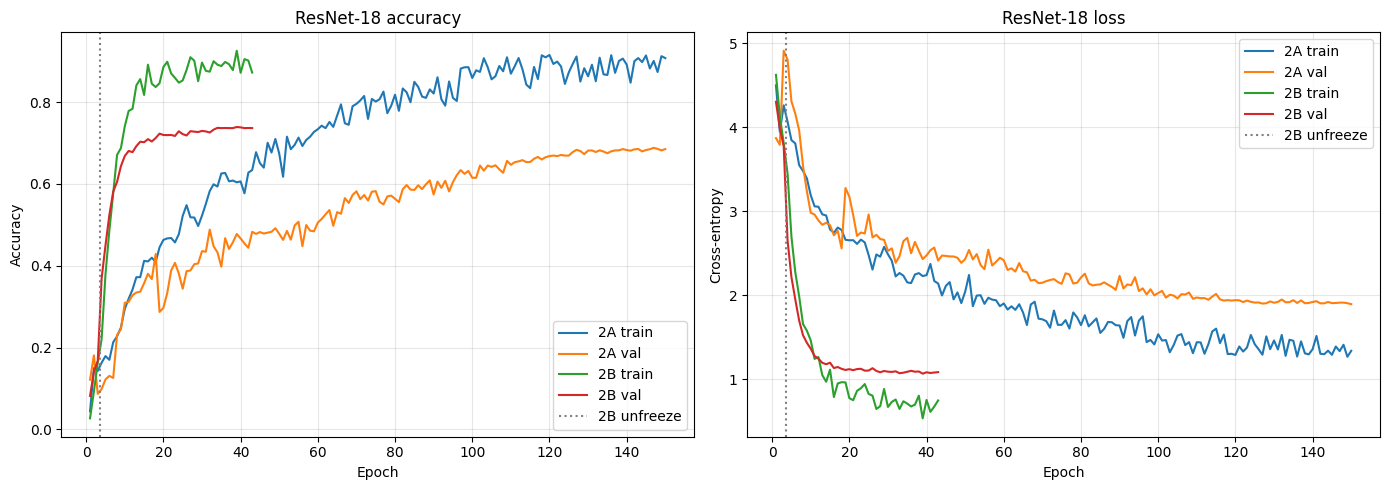

In [25]:
if RUN_STAGE == 3:
    def plot_resnet_comparison(base_history, tweaked_history, warmup_epochs):
        base_epochs = np.arange(1, len(base_history["val_acc"]) + 1)
        tweaked_epochs = np.arange(1, len(tweaked_history["val_acc"]) + 1)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].plot(base_epochs, base_history["train_acc"], label="2A train")
        axes[0].plot(base_epochs, base_history["val_acc"], label="2A val")
        axes[0].plot(tweaked_epochs, tweaked_history["train_acc"], label="2B train")
        axes[0].plot(tweaked_epochs, tweaked_history["val_acc"], label="2B val")
        axes[0].set(title="ResNet-18 accuracy", xlabel="Epoch", ylabel="Accuracy")

        axes[1].plot(base_epochs, base_history["train_loss"], label="2A train")
        axes[1].plot(base_epochs, base_history["val_loss"], label="2A val")
        axes[1].plot(tweaked_epochs, tweaked_history["train_loss"], label="2B train")
        axes[1].plot(tweaked_epochs, tweaked_history["val_loss"], label="2B val")
        axes[1].set(title="ResNet-18 loss", xlabel="Epoch", ylabel="Cross-entropy")

        for axis in axes:
            axis.axvline(
                warmup_epochs + 0.5,
                color="gray",
                linestyle=":",
                label="2B unfreeze",
            )
            axis.grid(alpha=0.3)
            axis.legend()

        plt.tight_layout()
        plt.show()


    plot_resnet_comparison(hist_rn_base, hist_rn_tweaked, WARMUP_EPOCHS)


### Part 2B results

Part 2B results shows a clear improvement. In fact, the transfer-learning-specific strategy provides an improvement of about five percentage points.

The classifier warm-up occupies the first three epochs. After the unfreezing point, shown by the vertical dotted line, both training and validation
accuracy improve sharply. This indicates that adapting the pretrained backbone is necessary for distinguishing the fine-grained aircraft variants:
the frozen ImageNet representation is useful, but full-network fine-tuning brings greater improvements.

Part 2B also converges much faster. It surpasses 70% validation accuracy after roughly 15 epochs and obtains its best results within 43 total epochs,
whereas Part 2A requires 150 epochs and finishes below 70%. Therefore, the higher input resolution, aircraft-preserving letterboxing, ImageNet normalization, staged unfreezing, and discriminative learning rates form a more effective and computationally efficient transfer-learning strategy.

Training accuracy approaches 90%, while validation accuracy stabilizes near 73-74%. This indicates some remaining overfitting, which is expected as before because the training split contains only about 33 images per aircraft class. Nevertheless, validation loss decreases rapidly and then remains stable
rather than increasing; this implies the presence of a generalization gap.

Overall, the results support the choices introduced in Part 2B:

- the frozen-head warm-up protects the pretrained representation during the
  initial adaptation;
- unfreezing allows the backbone to learn aircraft-specific features;
- the smaller backbone learning rate avoids excessively altering the
  pretrained parameters;
- higher-resolution, crop-free preprocessing preserves fine visual details;
- dropout, Mixup, and weight decay help limit overfitting.

## Final Test Evaluation

The final models are evaluated on the official test split only after all architectures, hyperparameters, and checkpoints have been selected using the
validation split. Test results are not used to revise the training procedure or select a model.

Each model is evaluated with the preprocessing used during its training:

- The custom CNN and ResNet-18 Part 2A use the original aircraft-normalized test loader.
- ResNet-18 Part 2B uses its dedicated ImageNet-normalized test loader, matching the preprocessing expected by the ImageNet-1K V1 weights.

The model used for detailed analysis is selected exclusively through its best validation accuracy.

In [26]:
if RUN_STAGE == 3:

    final_models = {
        "Custom CNN": model_custom_best,
        "ResNet-18 Part 2A": model_rn_base,
        "ResNet-18 Part 2B": model_rn_tweaked,
    }

    validation_scores = {
        "Custom CNN": fit_custom_best["best_val_acc"],
        "ResNet-18 Part 2A": fit_rn_base["best_val_acc"],
        "ResNet-18 Part 2B": fit_rn_tweaked["best_val_acc"],
    }

    # each model must receive the same type of preprocessing used during its training
    test_loaders = {
        "Custom CNN": test_loader,
        "ResNet-18 Part 2A": test_loader,
        "ResNet-18 Part 2B": resnet_test_loader,
    }

    # test results
    test_results = {
        name: evaluate_classifier(
            model=model,
            loader=test_loaders[name],
            criterion=criterion,
            num_classes=num_classes,
        )
        for name, model in final_models.items()
    }


    header = (
        f"{'Model':<24} "
        f"{'Best val':>10} "
        f"{'Test loss':>11} "
        f"{'Top-1 acc':>9} "
        f"{'Top-5 acc':>9} "
    )

    print(header)
    print("-" * len(header))

    for name in final_models:
        standard = test_results[name]

        print(
            f"{name:<24} "
            f"{validation_scores[name]:>10.4f} "
            f"{standard['loss']:>11.4f} "
            f"{standard['top1']:>9.4f} "
            f"{standard['top5']:>9.4f} "
        )

    selected_model_name = max(validation_scores, key=validation_scores.get)

    selected_model = final_models[selected_model_name]
    selected_loader = test_loaders[selected_model_name]

    selected_result = test_results[selected_model_name]


    if selected_model_name == "ResNet-18 Part 2B":
        selected_mean = IMAGENET_MEAN
        selected_std = IMAGENET_STD
    else:
        selected_mean = AIRCRAFT_MEAN
        selected_std = AIRCRAFT_STD

Model                      Best val   Test loss Top-1 acc Top-5 acc 
--------------------------------------------------------------------
Custom CNN                   0.5815      2.0728    0.6004    0.8806 
ResNet-18 Part 2A            0.6883      1.8943    0.6865    0.9109 
ResNet-18 Part 2B            0.7393      1.7099    0.7450    0.9265 


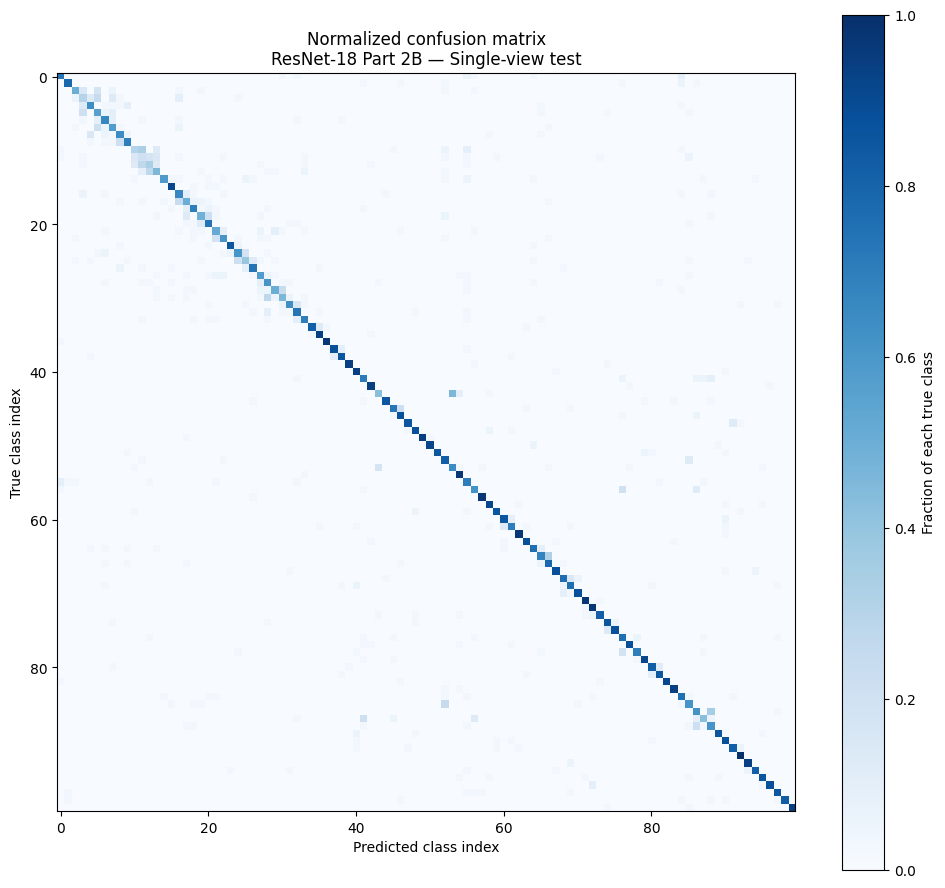

Top 12 observed single-view confusions by raw count:
 1. C-47 → DC-3: 15 images
 2. MD-80 → MD-90: 12 images
 3. 747-100 → 747-200: 11 images
 4. E-190 → E-195: 11 images
 5. 747-400 → 747-300: 9 images
 6. A340-300 → A330-300: 9 images
 7. 747-300 → 747-200: 9 images
 8. MD-11 → DC-10: 8 images
 9. 737-300 → 737-500: 8 images
10. A340-200 → A340-300: 8 images
11. 767-300 → 767-200: 8 images
12. CRJ-700 → CRJ-900: 7 images


In [27]:
if RUN_STAGE == 3:
    def plot_confusion_analysis(result, class_names, model_name, evaluation_name="Single-view test", top_n=12): # plots a row-normalized confusion matrix and lists common errors

        confusion = (
            result["confusion_matrix"]
            .detach()
            .cpu()
            .numpy()
        )

        if confusion.shape != (
            len(class_names),
            len(class_names),
        ):
            raise ValueError("The confusion-matrix dimensions do not match the number of class names.")

        row_totals = confusion.sum(
            axis=1,
            keepdims=True,
        )

        normalized = np.divide(
            confusion,
            row_totals,
            out=np.zeros_like(
                confusion,
                dtype=np.float64,
            ),
            where=row_totals != 0,
        )

        fig, ax = plt.subplots(figsize=(10, 9))

        matrix_image = ax.imshow(
            normalized,
            cmap="Blues",
            vmin=0.0,
            vmax=1.0,
            interpolation="nearest",
        )

        ax.set(
            title=(f"Normalized confusion matrix\n{model_name} — {evaluation_name}"),
            xlabel="Predicted class index",
            ylabel="True class index"
        )

        fig.colorbar(matrix_image,ax=ax,label="Fraction of each true class"
        )

        plt.tight_layout()
        plt.show()

        # to remove correct predictions before ranking errors
        off_diagonal = confusion.copy()
        np.fill_diagonal(off_diagonal, 0)

        ranked_indices = np.argsort(off_diagonal.ravel())[::-1]

        print(f"Top {top_n} observed single-view confusions by raw count:")

        shown = 0

        for flat_index in ranked_indices:
            count = int(off_diagonal.ravel()[flat_index])

            if count == 0 or shown >= top_n:
                break

            true_idx, predicted_idx = np.unravel_index(
                flat_index,
                off_diagonal.shape
            )

            print(f"{shown + 1:>2}. {class_names[true_idx]} → {class_names[predicted_idx]}: {count} images")

            shown += 1

        if shown == 0:
            print("No off-diagonal classification errors were found.")

    plot_confusion_analysis(
        result=selected_result,
        class_names=train_dataset.classes,
        model_name=selected_model_name,
        evaluation_name="Single-view test",
        top_n=12,
    )

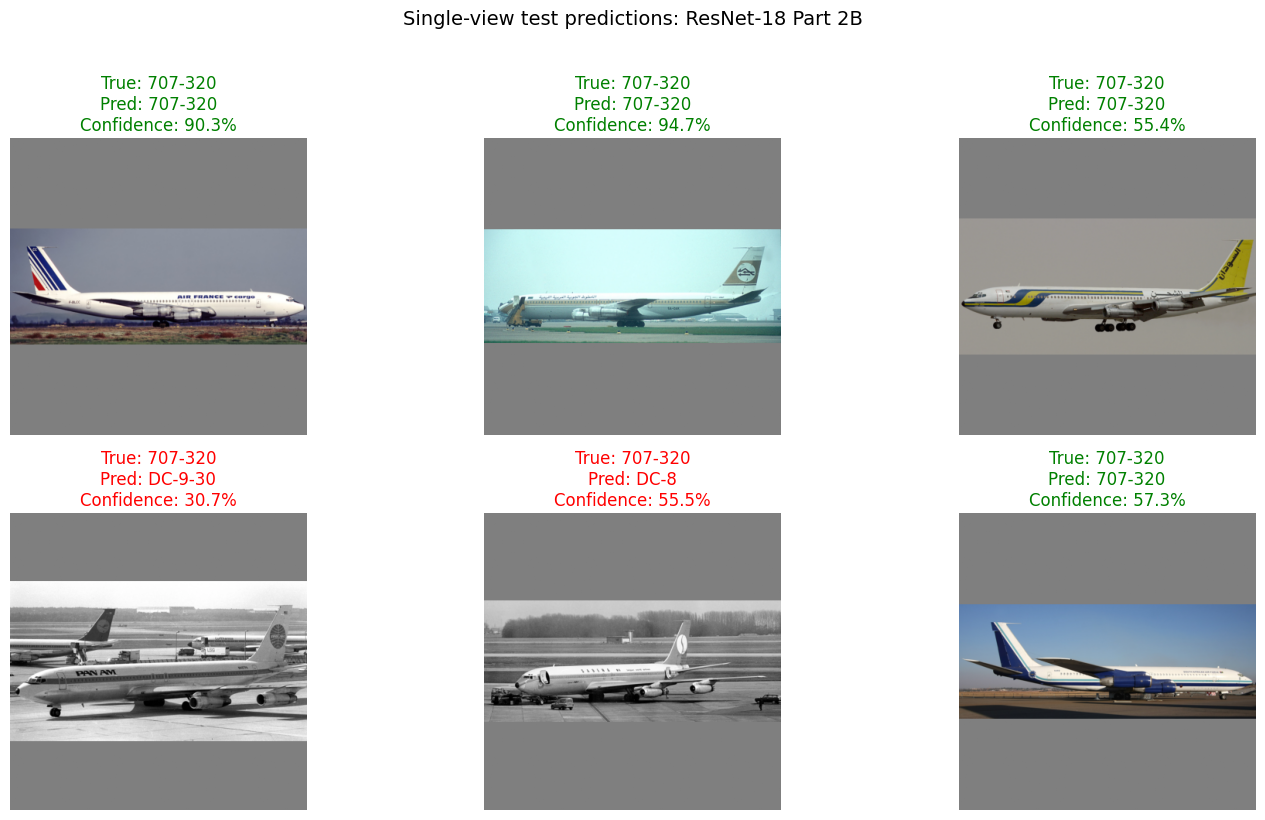

In [28]:
if RUN_STAGE == 3:
    @torch.inference_mode()
    def visualize_predictions(  # shows predictions
        model,
        dataloader,
        class_names,
        normalization_mean,
        normalization_std,
        model_name,
        num_images=6,
    ):

        model.eval()

        inputs, labels = next(iter(dataloader))

        if inputs.size(0) == 0:
            raise ValueError("The selected dataloader returned an empty batch.")

        inputs = inputs.to(device, non_blocking=PIN_MEMORY)

        logits = model(inputs)
        probabilities = logits.softmax(dim=1)

        confidences, predictions = probabilities.max(dim=1)

        # move information required for visualization back to the CPU
        inputs = inputs.detach().cpu()
        labels = labels.detach().cpu()
        predictions = predictions.detach().cpu()
        confidences = confidences.detach().cpu()

        num_images = min(num_images, inputs.size(0))

        columns = min(3, num_images)
        rows = int(np.ceil(num_images / columns))

        fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 4 * rows), squeeze=False)

        axes = axes.ravel()

        mean = np.asarray(normalization_mean, dtype=np.float32).reshape(1, 1, 3)

        std = np.asarray(normalization_std, dtype=np.float32).reshape(1, 1, 3)

        for index in range(num_images):
            image = (inputs[index].permute(1, 2, 0).numpy())

            # reverse the normalization applied by the selected loader.
            image = image * std + mean
            image = np.clip(image, 0.0, 1.0)

            true_idx = int(labels[index].item())
            predicted_idx = int(predictions[index].item())
            confidence = float(confidences[index].item())

            is_correct = (true_idx == predicted_idx)

            axes[index].imshow(image)

            axes[index].set_title(
                f"True: {class_names[true_idx]}\n"
                f"Pred: {class_names[predicted_idx]}\n"
                f"Confidence: {confidence:.1%}",
                color="green" if is_correct else "red"
            )

            axes[index].axis("off")

        # hide unused subplot positions
        for axis in axes[num_images:]:
            axis.axis("off")

        fig.suptitle(f"Single-view test predictions: {model_name}", fontsize=14, y=1.02)

        plt.tight_layout()
        plt.show()


    visualize_predictions(
        model=selected_model,
        dataloader=selected_loader,
        class_names=train_dataset.classes,
        normalization_mean=selected_mean,
        normalization_std=selected_std,
        model_name=selected_model_name,
        num_images=6,
    )

## References

- A. Zhang, Z. C. Lipton, M. Li, and A. J. Smola, [*Dive into Deep Learning*](https://d2l.ai/), Cambridge University Press, 2023.

- K. He et al., [*Deep Residual Learning for Image Recognition*](https://openaccess.thecvf.com/content_cvpr_2016/papers/He_Deep_Residual_Learning_CVPR_2016_paper.pdf), CVPR, 2016.

- J. Yosinski et al., [*How Transferable Are Features in Deep Neural Networks?*](https://proceedings.neurips.cc/paper_files/paper/2014/file/532a2f85b6977104bc93f8580abbb330-Paper.pdf), NeurIPS, 2014.

- H. Zhang et al., [*mixup: Beyond Empirical Risk Minimization*](https://arxiv.org/abs/1710.09412), ICLR, 2018.

- I. Loshchilov and F. Hutter, [*SGDR: Stochastic Gradient Descent with Warm Restarts*](https://arxiv.org/abs/1608.03983), ICLR, 2017.

- S. Maji et al., [*Fine-Grained Visual Classification of Aircraft*](https://arxiv.org/abs/1306.5151), arXiv:1306.5151, 2013.

- PyTorch, [*Transfer Learning for Computer Vision Tutorial*](https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html).
